# Optimización Bajo Incertidumbre (IIND 4125)

## Proyecto 2: Programación Estocástica

#### Daniel Velandia, Juan Aguirre y Sofía Acosta

In [123]:
import time
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

from scenarios_utils import (
    load_edges_from_csv,
    load_nodes_from_csv,
    generate_scenarios_table,
    build_scenario_data,
    build_base_data,
    summarize_instance,
    summarize_scenarios
)

# Cargar Instancia

In [124]:


INSTANCE = 69
N_SCENARIOS = 10
SEED = 123

edges = load_edges_from_csv("edges.csv")
nodes = load_nodes_from_csv("nodes.csv")

nodes = nodes[nodes["instance"] == INSTANCE].reset_index(drop=True)


dfD, dfU, dfc, dfp, dfG = generate_scenarios_table(
    nodes,
    edges,
    N=N_SCENARIOS,
    seed=SEED
)

omegas, p_omega, D, U_ew, c_ew, G_iw = build_scenario_data(
    dfD,
    dfU,
    dfc,
    dfG,
    dfp
)

base = build_base_data(
    nodes,
    edges,
    dfD=dfD,
    H_value=50.0,
    budget=2000.0
)


## 2. Componente algorítmico: tres estrategias de solución

En esta sección se comparan tres estrategias para resolver el mismo problema estocástico de dos etapas:

1. **Equivalente determinístico (DE):** resuelve la formulación extensiva completa en un solo modelo.
2. **Benders naive:** separa el problema en un master problem de primera etapa y subproblemas de segunda etapa por escenario.
3. **Branch-and-Cut con callbacks:** incorpora los cortes de Benders dentro del árbol de Branch & Bound de Gurobi usando lazy constraints.

El objetivo de esta comparación es analizar si las técnicas de descomposición permiten resolver el problema de forma más eficiente que la formulación extensiva.

In [125]:
DELTA_U = 0.8 # incremento de capacidad si se refuerza una línea
H_VALUE = 50 # costo de reforzar cada arco
BUDGET = 2500 # presupuesto total
PI = 190 # penalización por energía no servida
ALPHA = 0.95 # nivel CVaR

In [126]:
import networkx as nx

def plot_reinforced_network(nodes, edges, h_sol, title="Network with reinforced arcs"):
    G = nx.DiGraph()

    for n in nodes["node"].unique():
        G.add_node(int(n))

    for _, r in edges.iterrows():
        G.add_edge(
            int(r["i"]),
            int(r["j"]),
            e_id=int(r["e_id"])
        )

    reinforced_edges_ids = {
        e for e, val in h_sol.items()
        if val > 0.5
    }

    edge_colors = []
    edge_widths = []

    for u, v, data in G.edges(data=True):
        e_id = data["e_id"]

        if e_id in reinforced_edges_ids:
            edge_colors.append("red")
            edge_widths.append(3.0)
        else:
            edge_colors.append("lightgray")
            edge_widths.append(0.8)

    node_colors = []
    node_sizes = []

    gen_nodes = set(nodes.loc[nodes["is_generator"] == True, "node"].astype(int))

    for n in G.nodes():
        if n in gen_nodes:
            node_colors.append("lightgreen")
            node_sizes.append(450)
        else:
            node_colors.append("lightblue")
            node_sizes.append(180)

    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(13, 9))

    nx.draw_networkx_edges(
        G,
        pos,
        edge_color=edge_colors,
        width=edge_widths,
        arrows=True,
        arrowsize=8,
        alpha=0.85
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="black",
        linewidths=0.5
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=7
    )

    reinforced_labels = {
        (u, v): data["e_id"]
        for u, v, data in G.edges(data=True)
        if data["e_id"] in reinforced_edges_ids
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=reinforced_labels,
        font_size=7,
        font_color="red"
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## 2.1. Modelo equivalente determinístico

In [127]:
def solve_DE(base, omegas, p_omega, D, U_ew, c_ew, G_iw):

    nodes_list = base["nodes_list"]
    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]
    gen_nodes = base["gen_nodes"]
    in_arcs = base["in_arcs"]
    out_arcs = base["out_arcs"]
    H_e = base["H_e"]

    start = time.time()

    m = gp.Model("DE")
    m.Params.OutputFlag = 0

    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")

    f = m.addVars(edges_list, omegas, lb=0)
    delta = m.addVars(demand_nodes, omegas, lb=0)
    g = m.addVars(gen_nodes, omegas, lb=0)

    invest = gp.quicksum(H_e[e] * h[e] for e in edges_list)

    expected_cost = gp.quicksum(
        p_omega[w] * (
            gp.quicksum(c_ew[w, e] * f[e, w] for e in edges_list)
            +
            PI * gp.quicksum(delta[i, w] for i in demand_nodes)
        )
        for w in omegas
    )

    m.setObjective(invest + expected_cost, GRB.MINIMIZE)

    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= BUDGET
    )

    for w in omegas:

        for i in nodes_list:

            inflow = gp.quicksum(f[e, w] for e in in_arcs[i])
            outflow = gp.quicksum(f[e, w] for e in out_arcs[i])

            if i in demand_nodes:

                m.addConstr(
                    inflow - outflow == D[w, i] - delta[i, w]
                )

                m.addConstr(
                    delta[i, w] <= D[w, i]
                )

            elif i in gen_nodes:

                m.addConstr(
                    inflow - outflow == -g[i, w]
                )

                m.addConstr(
                    g[i, w] <= G_iw[w, i]
                )

            else:

                m.addConstr(
                    inflow - outflow == 0
                )

        for e in edges_list:

            m.addConstr(
                f[e, w] <= U_ew[w, e] * (1 + DELTA_U * h[e])
            )

    m.optimize()

    runtime = time.time() - start

    h_sol = {e: round(h[e].X) for e in edges_list}

    reinforced_edges = [e for e in edges_list if h_sol[e] > 0.5]

    return {
        "objective": m.ObjVal,
        "runtime": runtime,
        "h_sol": h_sol,
        "reinforced_edges": reinforced_edges,
        "num_selected_edges": len(reinforced_edges)
    }

de_results = solve_DE(
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw
)

de_results

{'objective': 219404.953757131,
 'runtime': 0.2013084888458252,
 'h_sol': {0: 0,
  1: 0,
  2: 0,
  3: 0,
  4: 0,
  5: 0,
  6: 0,
  7: 0,
  8: 0,
  9: 0,
  10: 0,
  11: 0,
  12: 0,
  13: 0,
  14: 0,
  15: 0,
  16: 0,
  17: 0,
  18: 0,
  19: 0,
  20: 0,
  21: 1,
  22: 0,
  23: 0,
  24: 0,
  25: 0,
  26: 0,
  27: 0,
  28: 0,
  29: 0,
  30: 0,
  31: 0,
  32: 0,
  33: 0,
  34: 1,
  35: 0,
  36: 0,
  37: 0,
  38: 0,
  39: 0,
  40: 0,
  41: 1,
  42: 0,
  43: 0,
  44: 0,
  45: 0,
  46: 0,
  47: 0,
  48: 1,
  49: 0,
  50: 0,
  51: 0,
  52: 0,
  53: 0,
  54: 0,
  55: 0,
  56: 0,
  57: 0,
  58: 1,
  59: 1,
  60: 0,
  61: 0,
  62: 0,
  63: 1,
  64: 0,
  65: 0,
  66: 0,
  67: 0,
  68: 0,
  69: 0,
  70: 0,
  71: 0,
  72: 0,
  73: 0,
  74: 0,
  75: 0,
  76: 0,
  77: 0,
  78: 0,
  79: 0,
  80: 0,
  81: 0,
  82: 0,
  83: 0,
  84: 0,
  85: 0,
  86: 0,
  87: 0,
  88: 0,
  89: 0,
  90: 0,
  91: 0,
  92: 0,
  93: 1,
  94: 1,
  95: 0,
  96: 0,
  97: 0,
  98: 0,
  99: 0,
  100: 0,
  101: 0,
  102: 0,
  103: 

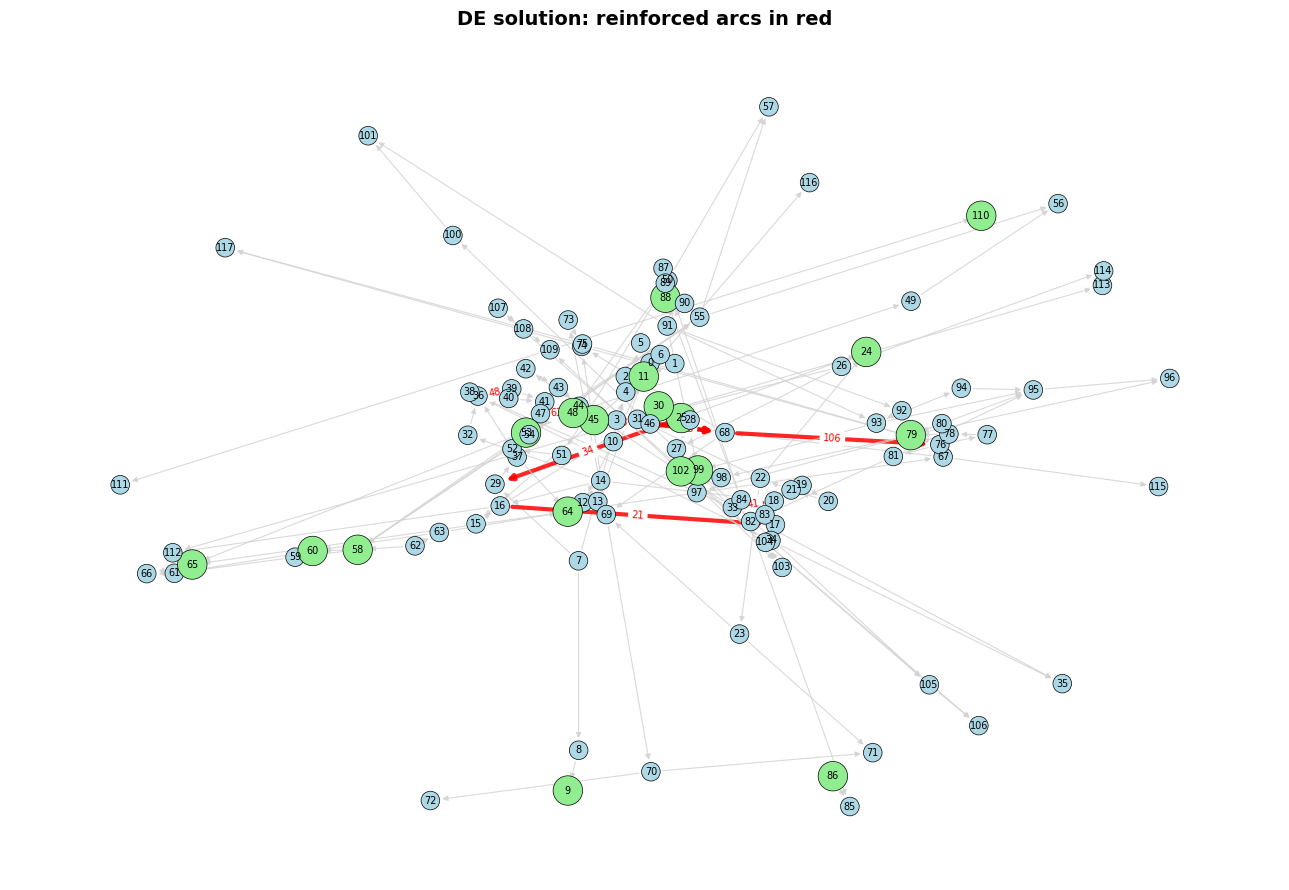

In [128]:
plot_reinforced_network(
    nodes,
    edges,
    de_results["h_sol"],
    title="DE solution: reinforced arcs in red"
)

## 2.2. Benders Naive

In [129]:
def solve_second_stage(w, h_hat, base, D, U_ew, c_ew, G_iw,
                       delta_u=DELTA_U, pi=PI, verbose=False):
    """
    Resuelve el subproblema de segunda etapa para un escenario fijo w
    y una decisión de inversión h_hat.

    Retorna:
        - objective: costo óptimo de segunda etapa Q_w(h_hat)
        - dual_cap: diccionario con los multiplicadores duales asociados
                    a las restricciones de capacidad de cada arco.
        - operating_cost, ens_cost: desglose de costos
        - delta: diccionario {nodo: demanda no servida} (solo nodos de demanda)
        - generation: diccionario {nodo: generación utilizada} (solo nodos generadores)
    """

    nodes_list = base["nodes_list"]
    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]
    gen_nodes = base["gen_nodes"]
    in_arcs = base["in_arcs"]
    out_arcs = base["out_arcs"]

    sp = gp.Model(f"SP_w{w}")
    if not verbose:
        sp.Params.OutputFlag = 0

    f = sp.addVars(edges_list, lb=0, name="f")
    delta = sp.addVars(demand_nodes, lb=0, name="delta")
    g = sp.addVars(gen_nodes, lb=0, name="g")

    # Restricciones de capacidad
    cap_constr = {}
    for e in edges_list:
        cap_constr[e] = sp.addConstr(
            f[e] <= U_ew[(w, e)] * (1 + delta_u * h_hat[e]),
            name=f"cap_e{e}"
        )

    # Límites de generación
    for i in gen_nodes:
        sp.addConstr(
            g[i] <= G_iw[(w, i)],
            name=f"gen_i{i}"
        )

    # Límite de demanda no servida
    for i in demand_nodes:
        sp.addConstr(
            delta[i] <= D[(w, i)],
            name=f"delta_i{i}"
        )

    # Balance de flujo
    for i in nodes_list:
        inflow = gp.quicksum(f[e] for e in in_arcs.get(i, []))
        outflow = gp.quicksum(f[e] for e in out_arcs.get(i, []))

        if i in demand_nodes:
            sp.addConstr(
                inflow - outflow == D[(w, i)] - delta[i],
                name=f"balance_demand_i{i}"
            )

        elif i in gen_nodes:
            sp.addConstr(
                inflow - outflow == -g[i],
                name=f"balance_gen_i{i}"
            )

        else:
            sp.addConstr(
                inflow - outflow == 0,
                name=f"balance_trans_i{i}"
            )

    operating_cost = gp.quicksum(c_ew[(w, e)] * f[e] for e in edges_list)
    ens_cost = pi * gp.quicksum(delta[i] for i in demand_nodes)

    sp.setObjective(operating_cost + ens_cost, GRB.MINIMIZE)

    sp.optimize()

    if sp.Status != GRB.OPTIMAL:
        print(f"Subproblema escenario {w} no óptimo. Status: {sp.Status}")
        return None

    Q_w = sp.ObjVal

    dual_cap = {
        e: cap_constr[e].Pi
        for e in edges_list
    }

    delta_sol = {
        i: delta[i].X
        for i in demand_nodes
    }

    g_sol = {
        i: g[i].X
        for i in gen_nodes
    }

    return {
        "objective": Q_w,
        "dual_cap": dual_cap,
        "operating_cost": sum(c_ew[(w, e)] * f[e].X for e in edges_list),
        "ens_cost": pi * sum(delta[i].X for i in demand_nodes),
        "delta": delta_sol,
        "generation": g_sol
    }

In [130]:
def evaluate_solution(h_hat, base, omegas, p_omega, D, U_ew, c_ew, G_iw,
                      delta_u=DELTA_U, pi=PI, verbose=False):
    """
    Evalúa una solución fija h_hat en todos los escenarios.

    Retorna:
    - costo total esperado,
    - costo de inversión,
    - costo esperado de segunda etapa,
    - costos por escenario.
    """

    edges_list = base["edges_list"]
    H_e = base["H_e"]

    investment_cost = sum(
        H_e[e] * h_hat[e]
        for e in edges_list
    )

    rows = []
    expected_second_stage = 0.0

    for w in omegas:

        sp_res = solve_second_stage(
            w=w,
            h_hat=h_hat,
            base=base,
            D=D,
            U_ew=U_ew,
            c_ew=c_ew,
            G_iw=G_iw,
            delta_u=delta_u,
            pi=pi,
            verbose=verbose
        )

        if sp_res is None:
            raise RuntimeError(f"No se pudo resolver el escenario {w}")

        Q_w = sp_res["objective"]

        expected_second_stage += p_omega[w] * Q_w

        rows.append({
            "omega": w,
            "p_omega": p_omega[w],
            "second_stage_cost": Q_w,
            "operating_cost": sp_res["operating_cost"],
            "ens_cost": sp_res["ens_cost"],
            "total_cost_scenario": investment_cost + Q_w,
            "total_deficit": sum(sp_res["delta"].values())
        })

    total_expected_cost = investment_cost + expected_second_stage

    return {
        "total_expected_cost": total_expected_cost,
        "investment_cost": investment_cost,
        "expected_second_stage": expected_second_stage,
        "scenario_costs": pd.DataFrame(rows)
    }

In [131]:
def add_combinatorial_cut(model, z_var, h_vars, h_hat, Q_hat,
                          edges_list, name="comb_cut"):
    """
    Agrega un corte combinatorio de Benders.

    Si h es igual a h_hat, entonces z >= Q_hat.
    Si h es diferente, el corte se relaja.
    """

    ones = [e for e in edges_list if h_hat[e] >= 0.5]
    zeros = [e for e in edges_list if h_hat[e] < 0.5]

    expr = 1

    expr -= gp.quicksum(1 - h_vars[e] for e in ones)
    expr -= gp.quicksum(h_vars[e] for e in zeros)

    model.addConstr(
        z_var >= Q_hat * expr,
        name=name
    )

In [132]:
def solve_benders_naive(base, omegas, p_omega, D, U_ew, c_ew, G_iw,
                        delta_u=DELTA_U, budget=BUDGET, pi=PI,
                        max_iter=100, tol=1e-4, time_limit=None, verbose=True):
    """
    Algoritmo de Benders desagregado naive con cortes duales clásicos.

    El master decide h_e y z_w.
    Los subproblemas devuelven Q_w y duales.
    Se agrega un corte por escenario cuando z_w subestima Q_w.
    """

    start_time = time.time()

    edges_list = base["edges_list"]
    H_e = base["H_e"]

    master = gp.Model("Benders_Naive")
    master.Params.OutputFlag = 0

    if time_limit is not None:
        master.Params.TimeLimit = time_limit

    h = master.addVars(edges_list, vtype=GRB.BINARY, name="h")
    z = master.addVars(omegas, lb=0, name="z")

    master.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    master.setObjective(
        gp.quicksum(H_e[e] * h[e] for e in edges_list)
        +
        gp.quicksum(p_omega[w] * z[w] for w in omegas),
        GRB.MINIMIZE
    )

    LB_history = []
    UB_history = []
    cuts_added_history = []

    UB = float("inf")
    best_h = None
    best_eval = None
    total_cuts = 0

    for it in range(1, max_iter + 1):

        master.optimize()

        if master.Status not in [GRB.OPTIMAL, GRB.TIME_LIMIT]:
            print("Master no óptimo. Status:", master.Status)
            break

        LB = master.ObjVal

        h_hat = {
            e: round(h[e].X)
            for e in edges_list
        }

        z_hat = {
            w: z[w].X
            for w in omegas
        }

        expected_second_stage = 0.0
        cuts_this_iter = 0

        for w in omegas:

            sp_res = solve_second_stage(
                w=w,
                h_hat=h_hat,
                base=base,
                D=D,
                U_ew=U_ew,
                c_ew=c_ew,
                G_iw=G_iw,
                delta_u=delta_u,
                pi=pi,
                verbose=False
            )

            if sp_res is None:
                raise RuntimeError(f"Subproblema no óptimo en escenario {w}")

            Q_w = sp_res["objective"]
            dual_cap = sp_res["dual_cap"]

            expected_second_stage += p_omega[w] * Q_w

            if z_hat[w] < Q_w - tol:

                expr = Q_w + gp.quicksum(
                    dual_cap[e] * U_ew[(w, e)] * delta_u * (h[e] - h_hat[e])
                    for e in edges_list
                )

                master.addConstr(
                    z[w] >= expr,
                    name=f"benders_cut_{it}_{w}"
                )

                cuts_this_iter += 1
                total_cuts += 1

        investment_cost = sum(
            H_e[e] * h_hat[e]
            for e in edges_list
        )

        current_UB = investment_cost + expected_second_stage

        if current_UB < UB:
            UB = current_UB
            best_h = h_hat.copy()
            best_eval = {
                "investment_cost": investment_cost,
                "expected_second_stage": expected_second_stage
            }

        LB_history.append(LB)
        UB_history.append(UB)
        cuts_added_history.append(cuts_this_iter)

        gap = abs(UB - LB) / max(1, abs(UB))

        if verbose:
            print(
                f"Iter {it:03d} | "
                f"LB={LB:.4f} | "
                f"UB={UB:.4f} | "
                f"Gap={gap:.6f} | "
                f"Cortes={cuts_this_iter}"
            )

        if cuts_this_iter == 0 and gap <= tol:
            if verbose:
                print("Convergencia alcanzada.")
            break

    runtime = time.time() - start_time

    if best_h is None:
        raise RuntimeError("Benders no encontró una solución factible.")

    return {
        "objective": UB,
        "runtime": runtime,
        "best_h": best_h,
        "h_sol": best_h,
        "selected_edges": [e for e in edges_list if best_h[e] > 0.5],
        "num_selected_edges": sum(best_h[e] for e in edges_list),
        "investment_cost": best_eval["investment_cost"],
        "expected_second_stage": best_eval["expected_second_stage"],
        "iterations": it,
        "total_cuts": total_cuts,
        "LB_history": LB_history,
        "UB_history": UB_history,
        "cuts_added_history": cuts_added_history,
        "master_model": master
    }

In [133]:

benders_results = solve_benders_naive(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    max_iter=100,
    tol=1e-4,
    verbose=True
)

print("RESULTADOS BENDERS NAIVE")
print("Objetivo Benders:", benders_results["objective"])
print("Tiempo:", benders_results["runtime"])
print("Iteraciones:", benders_results["iterations"])
print("Cortes agregados:", benders_results["total_cuts"])
print("Costo inversión:", benders_results["investment_cost"])
print("Costo esperado segunda etapa:", benders_results["expected_second_stage"])
print("Arcos reforzados:", benders_results["num_selected_edges"])
print("Lista de arcos reforzados:", benders_results["selected_edges"])

print("\nCOMPARACIÓN CONTRA DE")
print("Objetivo DE:", de_results["objective"])
print("Objetivo Benders:", benders_results["objective"])
print("Diferencia absoluta:", abs(de_results["objective"] - benders_results["objective"]))

Iter 001 | LB=0.0000 | UB=237248.5222 | Gap=1.000000 | Cortes=10
Iter 002 | LB=198712.9424 | UB=219499.3562 | Gap=0.094699 | Cortes=10
Iter 003 | LB=218265.6145 | UB=219499.3562 | Gap=0.005621 | Cortes=10
Iter 004 | LB=218549.4270 | UB=219499.3562 | Gap=0.004328 | Cortes=7
Iter 005 | LB=218818.0147 | UB=219398.2812 | Gap=0.002645 | Cortes=2
Iter 006 | LB=219398.2812 | UB=219398.2812 | Gap=0.000000 | Cortes=0
Convergencia alcanzada.
RESULTADOS BENDERS NAIVE
Objetivo Benders: 219398.2812130186
Tiempo: 0.731665849685669
Iteraciones: 6
Cortes agregados: 39
Costo inversión: 500.0
Costo esperado segunda etapa: 218898.2812130186
Arcos reforzados: 10
Lista de arcos reforzados: [21, 34, 41, 48, 58, 59, 63, 93, 94, 106]

COMPARACIÓN CONTRA DE
Objetivo DE: 219404.953757131
Objetivo Benders: 219398.2812130186
Diferencia absoluta: 6.672544112399919


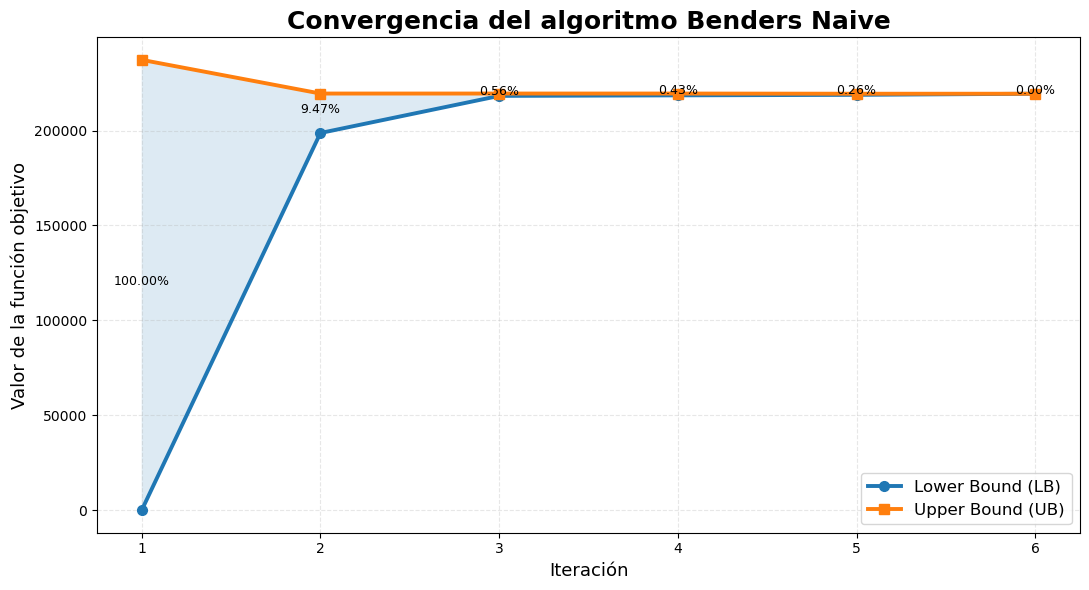

In [134]:
LB = benders_results["LB_history"]
UB = benders_results["UB_history"]

iters = np.arange(1, len(LB) + 1)

gap_pct = [
    100 * abs(UB[i] - LB[i]) / max(1, abs(UB[i]))
    for i in range(len(LB))
]

plt.figure(figsize=(11, 6))

# Curva LB
plt.plot(
    iters,
    LB,
    marker="o",
    linewidth=2.8,
    markersize=7,
    label="Lower Bound (LB)"
)

# Curva UB
plt.plot(
    iters,
    UB,
    marker="s",
    linewidth=2.8,
    markersize=7,
    label="Upper Bound (UB)"
)

# Área sombreada entre LB y UB
plt.fill_between(
    iters,
    LB,
    UB,
    alpha=0.15
)

# Mostrar gap %
for i in range(len(iters)):
    plt.text(
        iters[i],
        (LB[i] + UB[i]) / 2,
        f"{gap_pct[i]:.2f}%",
        fontsize=9,
        ha="center"
    )

plt.title(
    "Convergencia del algoritmo Benders Naive",
    fontsize=18,
    weight="bold"
)

plt.xlabel(
    "Iteración",
    fontsize=13
)

plt.ylabel(
    "Valor de la función objetivo",
    fontsize=13
)

plt.xticks(iters)

plt.grid(
    alpha=0.3,
    linestyle="--"
)

plt.legend(
    fontsize=12
)

plt.tight_layout()

plt.savefig(
    "benders_convergence_beautiful.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 2.3. Branch and Cut

In [135]:
def solve_benders_callback(
    base, omegas, p_omega, D, U_ew, c_ew, G_iw,
    delta_u=DELTA_U, budget=BUDGET, pi=PI,
    tol=1e-4, time_limit=None, verbose=True
):
    start_time = time.time()

    edges_list = base["edges_list"]
    H_e = base["H_e"]

    m = gp.Model("Branch_and_Cut_Benders")
    m.Params.LazyConstraints = 1

    if not verbose:
        m.Params.OutputFlag = 0
    if time_limit is not None:
        m.Params.TimeLimit = time_limit

    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")
    z = m.addVars(omegas, lb=0.0, name="z")

    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    m.setObjective(
        gp.quicksum(H_e[e] * h[e] for e in edges_list)
        + gp.quicksum(p_omega[w] * z[w] for w in omegas),
        GRB.MINIMIZE
    )

    m._cuts = 0
    m._incumbent_log = []

    def callback(model, where):
        if where == GRB.Callback.MIPSOL:

            h_sol = {
                e: round(model.cbGetSolution(h[e]))
                for e in edges_list
            }

            z_sol = {
                w: model.cbGetSolution(z[w])
                for w in omegas
            }

            cuts_this_solution = 0
            expected_second_stage = 0.0

            for w in omegas:

                sp_res = solve_second_stage(
                    w=w,
                    h_hat=h_sol,
                    base=base,
                    D=D,
                    U_ew=U_ew,
                    c_ew=c_ew,
                    G_iw=G_iw,
                    delta_u=delta_u,
                    pi=pi,
                    verbose=False
                )

                if sp_res is None:
                    continue

                Q_w = sp_res["objective"]
                dual_cap = sp_res["dual_cap"]

                expected_second_stage += p_omega[w] * Q_w

                if z_sol[w] < Q_w - tol:

                    expr = Q_w + gp.quicksum(
                        dual_cap[e] * U_ew[(w, e)] * delta_u * (h[e] - h_sol[e])
                        for e in edges_list
                    )

                    model.cbLazy(z[w] >= expr)

                    model._cuts += 1
                    cuts_this_solution += 1

            investment_cost = sum(H_e[e] * h_sol[e] for e in edges_list)

            model._incumbent_log.append({
                "investment_cost": investment_cost,
                "expected_second_stage": expected_second_stage,
                "evaluated_total_cost": investment_cost + expected_second_stage,
                "cuts_added": cuts_this_solution
            })

    m.optimize(callback)

    runtime = time.time() - start_time

    if m.Status != GRB.OPTIMAL:
        print("OJO: Branch-and-Cut no terminó óptimo. Status:", m.Status)

    h_sol = {e: round(h[e].X) for e in edges_list}

    eval_final = evaluate_solution(
        h_hat=h_sol,
        base=base,
        omegas=omegas,
        p_omega=p_omega,
        D=D,
        U_ew=U_ew,
        c_ew=c_ew,
        G_iw=G_iw,
        delta_u=delta_u,
        pi=pi,
        verbose=False
    )

    selected_edges = [e for e in edges_list if h_sol[e] > 0.5]

    return {
        "objective": eval_final["total_expected_cost"],
        "master_objective": m.ObjVal,
        "runtime": runtime,
        "h_sol": h_sol,
        "selected_edges": selected_edges,
        "num_selected_edges": len(selected_edges),
        "investment_cost": eval_final["investment_cost"],
        "expected_second_stage": eval_final["expected_second_stage"],
        "total_cuts": m._cuts,
        "incumbent_log": pd.DataFrame(m._incumbent_log),
        "model": m
    }

In [136]:
callback_results = solve_benders_callback(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw,
    tol=1e-4,
    verbose=True
)

print("DE:", de_results["objective"])
print("Benders:", benders_results["objective"])
print("Branch-and-Cut:", callback_results["objective"])

print("Diff DE vs B&C:", abs(de_results["objective"] - callback_results["objective"]))
print("Arcos B&C:", callback_results["selected_edges"])

Set parameter LazyConstraints to value 1
Gurobi Optimizer version 12.0.1 build v12.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i7-10750H CPU @ 2.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Non-default parameters:
LazyConstraints  1

Optimize a model with 1 rows, 189 columns and 179 nonzeros
Model fingerprint: 0xfaf9f4ee
Variable types: 10 continuous, 179 integer (179 binary)
Coefficient statistics:
  Matrix range     [5e+01, 5e+01]
  Objective range  [1e-01, 5e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [3e+03, 3e+03]
Presolve time: 0.00s
Presolved: 1 rows, 189 columns, 179 nonzeros
Variable types: 10 continuous, 179 integer (179 binary)

Root relaxation: objective 1.987129e+05, 5 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time



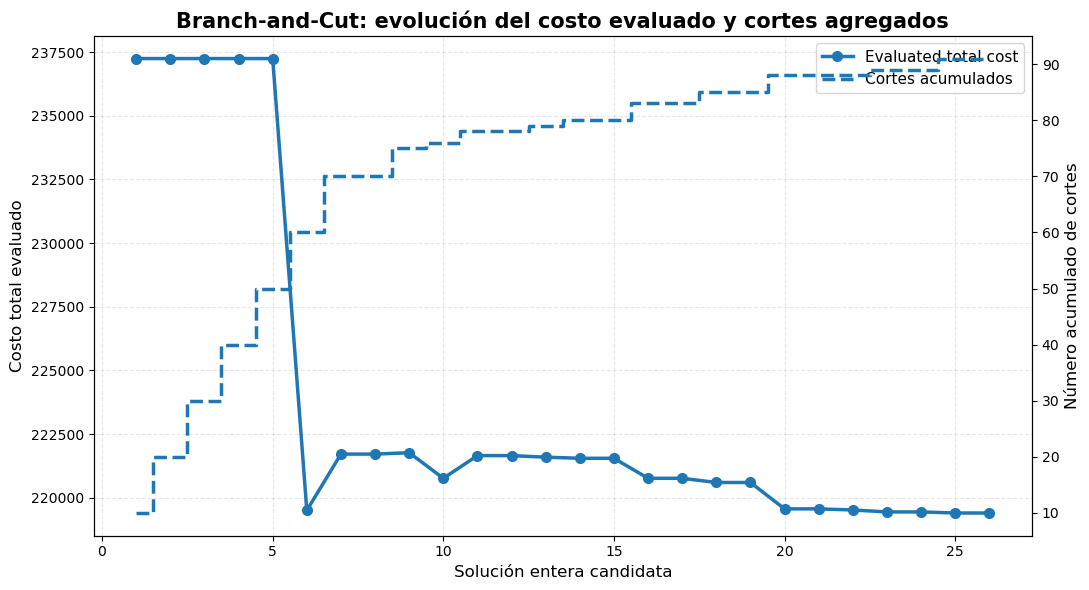

In [137]:
import matplotlib.pyplot as plt
import numpy as np

bc_log = callback_results["incumbent_log"].copy()

bc_log["candidate"] = np.arange(1, len(bc_log) + 1)
bc_log["cumulative_cuts"] = bc_log["cuts_added"].cumsum()

fig, ax1 = plt.subplots(figsize=(11, 6))

# Costo evaluado de cada incumbent
ax1.plot(
    bc_log["candidate"],
    bc_log["evaluated_total_cost"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Evaluated total cost"
)

ax1.set_xlabel("Solución entera candidata", fontsize=12)
ax1.set_ylabel("Costo total evaluado", fontsize=12)
ax1.grid(alpha=0.3, linestyle="--")

# Eje secundario: cortes acumulados
ax2 = ax1.twinx()

ax2.step(
    bc_log["candidate"],
    bc_log["cumulative_cuts"],
    where="mid",
    linewidth=2.5,
    linestyle="--",
    label="Cortes acumulados"
)

ax2.set_ylabel("Número acumulado de cortes", fontsize=12)

# Título
plt.title(
    "Branch-and-Cut: evolución del costo evaluado y cortes agregados",
    fontsize=15,
    fontweight="bold"
)

# Leyenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="best",
    fontsize=11
)

plt.tight_layout()
plt.show()

## 2.4. Comparación estrategias de solución

In [138]:
def result_row(name, res, eval_res=None, iter_cuts="-"):
    h_sol = res.get("h_sol", {})
    selected = res.get("selected_edges", res.get("reinforced_edges", []))

    if eval_res is not None:
        investment_cost = eval_res["investment_cost"]
        expected_second_stage = eval_res["expected_second_stage"]
    else:
        investment_cost = res.get("investment_cost", np.nan)
        expected_second_stage = res.get("expected_second_stage", np.nan)

    return {
        "Método": name,
        "Objetivo": round(res["objective"], 2),
        "Tiempo (s)": round(res["runtime"], 2),
        "Iteraciones / Cortes": iter_cuts,
        "Costo inversión": round(investment_cost, 2),
        "Costo esperado 2da etapa": round(expected_second_stage, 2),
        "Arcos reforzados": len(selected),
        "Lista arcos": str(selected)
    }


de_eval = evaluate_solution(
    h_hat=de_results["h_sol"],
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw
)

comparison_algorithms = pd.DataFrame([
    result_row(
        "Deterministic Equivalent (DE)",
        de_results,
        eval_res=de_eval,
        iter_cuts="-"
    ),
    result_row(
        "Benders Naive",
        benders_results,
        iter_cuts=f'{benders_results["iterations"]} iter / {benders_results["total_cuts"]} cortes'
    ),
    result_row(
        "Branch-and-Cut",
        callback_results,
        iter_cuts=f'{callback_results["total_cuts"]} cortes'
    )
])

comparison_algorithms

,Método,Objetivo,Tiempo (s),Iteraciones / Cortes,Costo inversión,Costo esperado 2da etapa,Arcos reforzados,Lista arcos
0,Deterministic Equivalent (DE),219404.95,0.20,-,500.0,218898.28,10,"[21, 34, 41, 48, 58, 59, 63, 93, 94, 106]"
1,Benders Naive,219398.28,0.73,6 iter / 39 cortes,500.0,218898.28,10,"[21, 34, 41, 48, 58, 59, 63, 93, 94, 106]"
2,Branch-and-Cut,219398.28,3.22,91 cortes,500.0,218898.28,10,"[21, 34, 41, 48, 58, 59, 63, 93, 94, 106]"


## 3. Escalabilidad: SAA y efecto del número de escenarios N

En esta sección se analiza la estabilidad de la solución estocástica cuando cambia el número de escenarios utilizados en la aproximación SAA.

Para cada valor de N se generan varias réplicas independientes. Luego, para cada réplica, se resuelve el problema y se registran:

- valor objetivo,
- tiempo computacional,
- número de arcos reforzados.

Este experimento permite observar si la solución se estabiliza al aumentar N y cómo crece el esfuerzo computacional.

In [139]:
N_VALUES = [10, 25, 50, 100]
M_REPS = 20

### 3.1 Método de Muestreo: Monte Carlo

In [140]:
def solve_one_saa_replication(
    N,
    seed,
    solver="benders",
    K=None,
    verbose=False
):
    dfD_N, dfU_N, dfc_N, dfp_N, dfG_N = generate_scenarios_table(
        nodes,
        edges,
        N=N,
        K=K,
        seed=seed
    )

    omegas_N, p_N, D_N, U_N, c_N, G_N = build_scenario_data(
        dfD_N, dfU_N, dfc_N, dfG_N, dfp_N
    )

    base_N = build_base_data(
        nodes,
        edges,
        dfD=dfD_N,
        H_value=50.0,
        budget=BUDGET
    )

    start = time.time()

    if solver == "de":
        res = solve_DE(
            base_N, omegas_N, p_N, D_N, U_N, c_N, G_N
        )

    elif solver == "benders":
        res = solve_benders_naive(
            base=base_N,
            omegas=omegas_N,
            p_omega=p_N,
            D=D_N,
            U_ew=U_N,
            c_ew=c_N,
            G_iw=G_N,
            max_iter=100,
            tol=1e-4,
            verbose=verbose
        )

    elif solver == "branch_cut":
        res = solve_benders_callback(
            base=base_N,
            omegas=omegas_N,
            p_omega=p_N,
            D=D_N,
            U_ew=U_N,
            c_ew=c_N,
            G_iw=G_N,
            tol=1e-4,
            verbose=verbose
        )

    else:
        raise ValueError("solver must be 'de', 'benders', or 'branch_cut'")

    runtime = time.time() - start

    return {
        "N": N,
        "seed": seed,
        "solver": solver,
        "objective": res["objective"],
        "runtime": runtime,
        "num_selected_edges": res["num_selected_edges"],
        "selected_edges": res.get("selected_edges", [])
    }

In [141]:
def run_saa_stability_experiment(
    N_values=N_VALUES,
    M=M_REPS,
    solver="benders",
    seed0=1000
):
    rows = []

    for N in N_values:
        print(f"\nRunning SAA for N={N}")

        for m in range(M):
            seed = seed0 + 1000 * N + m

            try:
                out = solve_one_saa_replication(
                    N=N,
                    seed=seed,
                    solver=solver,
                    verbose=False
                )
                out["replication"] = m + 1
                rows.append(out)

                print(
                    f"N={N} | rep={m+1}/{M} | "
                    f"obj={out['objective']:.2f} | "
                    f"time={out['runtime']:.2f}s"
                )

            except Exception as e:
                print(f"Error en N={N}, rep={m+1}: {e}")

    return pd.DataFrame(rows)


saa_results = run_saa_stability_experiment(
    N_values=N_VALUES,
    M=M_REPS,
    solver="benders"
)

saa_results.head()


Running SAA for N=10
N=10 | rep=1/20 | obj=304308.14 | time=1.03s
N=10 | rep=2/20 | obj=384147.83 | time=0.91s
N=10 | rep=3/20 | obj=223501.77 | time=1.02s
N=10 | rep=4/20 | obj=221069.58 | time=0.74s
N=10 | rep=5/20 | obj=314141.65 | time=0.75s
N=10 | rep=6/20 | obj=253690.32 | time=0.95s
N=10 | rep=7/20 | obj=377079.50 | time=0.70s
N=10 | rep=8/20 | obj=304004.91 | time=0.68s
N=10 | rep=9/20 | obj=216481.98 | time=0.58s
N=10 | rep=10/20 | obj=222564.99 | time=0.82s
N=10 | rep=11/20 | obj=220076.99 | time=0.77s
N=10 | rep=12/20 | obj=299308.38 | time=0.74s
N=10 | rep=13/20 | obj=225292.76 | time=0.74s
N=10 | rep=14/20 | obj=297545.29 | time=0.53s
N=10 | rep=15/20 | obj=221335.69 | time=0.52s
N=10 | rep=16/20 | obj=301407.88 | time=0.74s
N=10 | rep=17/20 | obj=400053.35 | time=0.87s
N=10 | rep=18/20 | obj=399148.64 | time=0.65s
N=10 | rep=19/20 | obj=292867.43 | time=0.66s
N=10 | rep=20/20 | obj=221491.23 | time=0.54s

Running SAA for N=25
N=25 | rep=1/20 | obj=279964.71 | time=2.14s


,N,seed,solver,objective,runtime,num_selected_edges,selected_edges,replication
0,10,11000,benders,304308.139627,1.028011,9,"[21, 34, 48, 58, 59, 63, 93, 94, 106]",1
1,10,11001,benders,384147.833752,0.908639,11,"[21, 22, 34, 41, 48, 58, 59, 63, 93, 94, 106]",2
2,10,11002,benders,223501.768104,1.024167,11,"[21, 22, 34, 41, 48, 58, 59, 63, 93, 94, 106]",3
3,10,11003,benders,221069.581571,0.738352,8,"[21, 22, 41, 58, 59, 93, 94, 106]",4
4,10,11004,benders,314141.648679,0.753458,8,"[21, 22, 34, 41, 58, 93, 94, 106]",5


C:\Users\Usuario\AppData\Local\Temp\ipykernel_12968\682797486.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


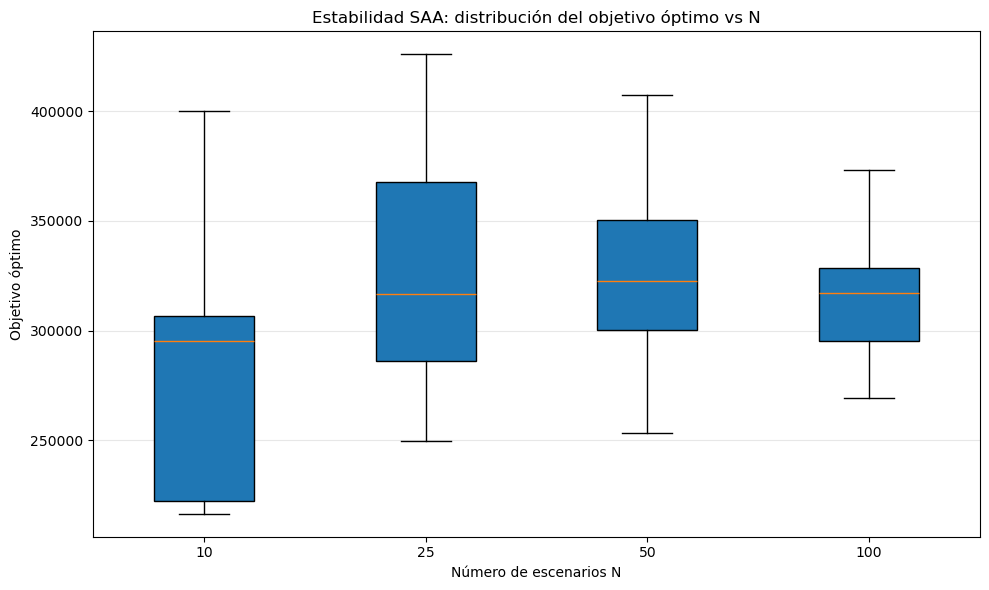

In [142]:
plt.figure(figsize=(10, 6))

data = [
    saa_results.loc[saa_results["N"] == N, "objective"].values
    for N in sorted(saa_results["N"].unique())
]

plt.boxplot(
    data,
    labels=sorted(saa_results["N"].unique()),
    patch_artist=True
)

plt.xlabel("Número de escenarios N")
plt.ylabel("Objetivo óptimo")
plt.title("Estabilidad SAA: distribución del objetivo óptimo vs N")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

El experimento SAA evalúa la estabilidad del valor objetivo al aumentar el número de escenarios. Para cada valor de \(N\), se generan múltiples réplicas independientes y se resuelve el problema estocástico. En teoría, al aumentar \(N\), la variabilidad del objetivo entre réplicas debería disminuir, ya que la muestra representa mejor la distribución verdadera de incertidumbre. Por tanto, una reducción en la dispersión de los boxplots indica mayor estabilidad del estimador SAA.

In [143]:
saa_summary = (
    saa_results
    .groupby("N")
    .agg(
        mean_objective=("objective", "mean"),
        std_objective=("objective", "std"),
        min_objective=("objective", "min"),
        max_objective=("objective", "max"),
        mean_runtime=("runtime", "mean")
    )
    .reset_index()
)

saa_summary

,N,mean_objective,std_objective,min_objective,max_objective,mean_runtime
0,10,284975.915813,64953.946939,216481.980463,400053.346705,0.747704
1,25,328616.401470,54073.993607,249499.817134,425919.509396,1.756036
2,50,326179.493576,38789.102446,253496.934403,407253.193982,3.374477
3,100,313905.412924,26363.682868,269420.286774,373061.698139,6.878240


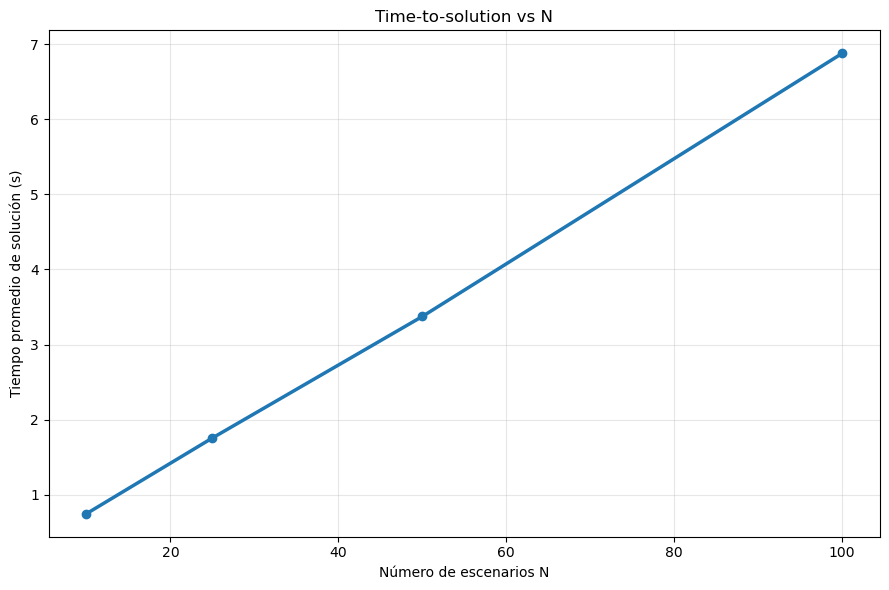

In [144]:
plt.figure(figsize=(9, 6))

plt.plot(
    saa_summary["N"],
    saa_summary["mean_runtime"],
    marker="o",
    linewidth=2.5
)

plt.xlabel("Número de escenarios N")
plt.ylabel("Tiempo promedio de solución (s)")
plt.title("Time-to-solution vs N")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Se grafica para benders, no para DE

### Comparación de métodos DE, Benders y Branch-and-Cut

In [145]:
def run_time_comparison(
    N_values=[10, 25, 50],
    seed0=5000
):
    rows = []

    for N in N_values:
        print(f"\nComparing methods for N={N}")

        for solver in ["de", "benders", "branch_cut"]:
            seed = seed0 + N

            try:
                out = solve_one_saa_replication(
                    N=N,
                    seed=seed,
                    solver=solver,
                    verbose=False
                )
                rows.append(out)

                print(
                    f"{solver} | N={N} | "
                    f"obj={out['objective']:.2f} | "
                    f"time={out['runtime']:.2f}s"
                )

            except Exception as e:
                print(f"Error {solver}, N={N}: {e}")

    return pd.DataFrame(rows)


time_comparison = run_time_comparison(
    N_values=[10, 25, 50]
)

time_comparison


Comparing methods for N=10
de | N=10 | obj=221045.52 | time=0.14s
benders | N=10 | obj=221041.87 | time=0.57s
Set parameter LazyConstraints to value 1
branch_cut | N=10 | obj=221041.87 | time=1.52s

Comparing methods for N=25
de | N=25 | obj=296515.35 | time=0.36s
benders | N=25 | obj=296515.18 | time=1.76s
Set parameter LazyConstraints to value 1
branch_cut | N=25 | obj=296515.18 | time=5.04s

Comparing methods for N=50
de | N=50 | obj=372509.29 | time=0.63s
benders | N=50 | obj=372509.29 | time=3.86s
Set parameter LazyConstraints to value 1
branch_cut | N=50 | obj=372509.29 | time=11.47s


,N,seed,solver,objective,runtime,num_selected_edges,selected_edges
0,10,5010,de,221045.518321,0.140877,9,[]
1,10,5010,benders,221041.869787,0.568025,9,"[21, 22, 34, 41, 48, 58, 93, 94, 106]"
2,10,5010,branch_cut,221041.869787,1.517098,9,"[21, 22, 34, 41, 48, 58, 93, 94, 106]"
3,25,5025,de,296515.345507,0.360337,11,[]
4,25,5025,benders,296515.183985,1.762429,11,"[21, 22, 34, 41, 48, 58, 59, 63, 93, 94, 106]"
5,25,5025,branch_cut,296515.183985,5.043817,11,"[21, 22, 34, 41, 48, 58, 59, 63, 93, 94, 106]"
6,50,5050,de,372509.289408,0.628924,13,[]
7,50,5050,benders,372509.289408,3.862925,13,"[21, 22, 34, 41, 48, 58, 59, 63, 93, 94, 106, ..."
8,50,5050,branch_cut,372509.289408,11.467837,13,"[21, 22, 34, 41, 48, 58, 59, 63, 93, 94, 106, ..."


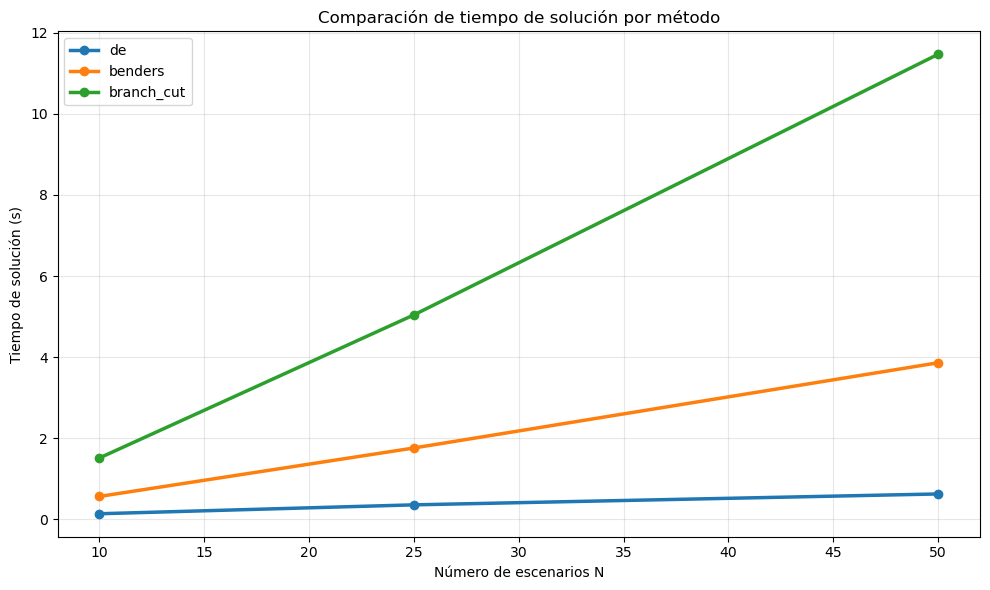

In [146]:
plt.figure(figsize=(10, 6))

for solver in time_comparison["solver"].unique():
    df_s = time_comparison[time_comparison["solver"] == solver]

    plt.plot(
        df_s["N"],
        df_s["runtime"],
        marker="o",
        linewidth=2.5,
        label=solver
    )

plt.xlabel("Número de escenarios N")
plt.ylabel("Tiempo de solución (s)")
plt.title("Comparación de tiempo de solución por método")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Monte Carlo vs LHS

In [147]:
from scipy.stats import qmc, norm, lognorm

def generate_scenarios_table_lhs(
    nodes,
    edges,
    N,
    seed=123,
    p_crisis=0.05,
    dem_sigma=0.10,
    cost_sigma=0.05,
    crisis_dem_mult_mu=2.0,
    crisis_dem_mult_sigma=0.25,
    crisis_cost_mult=2.0,
    p_outage=0.02,
    cap_drop=0.7,
    gen_sigma=0.05
):
    rng = np.random.default_rng(seed)

    sampler = qmc.LatinHypercube(d=5, seed=seed)
    U_lhs = sampler.random(N)

    dfD_rows = []
    dfU_rows = []
    dfc_rows = []
    dfG_rows = []
    dfp_rows = []

    nodes_tmp = nodes.copy()
    edges_tmp = edges.copy()

    if "U_base" not in edges_tmp.columns:
        if "f_max" in edges_tmp.columns:
            edges_tmp["U_base"] = edges_tmp["f_max"]
        else:
            edges_tmp["U_base"] = 100.0

    if "c_base" not in edges_tmp.columns:
        edges_tmp["c_base"] = 1.0

    for w in range(N):
        u_crisis, u_dem, u_cost, u_cap, u_gen = U_lhs[w]

        crisis = u_crisis < p_crisis

        # Demand multiplier
        if crisis:
            dem_mult = lognorm.ppf(
                max(u_dem, 1e-6),
                s=crisis_dem_mult_sigma,
                scale=crisis_dem_mult_mu
            )
        else:
            dem_mult = norm.ppf(
                min(max(u_dem, 1e-6), 1 - 1e-6),
                loc=1.0,
                scale=dem_sigma
            )
            dem_mult = max(dem_mult, 0.0)

        # Cost multiplier
        if crisis:
            cost_mult = crisis_cost_mult
        else:
            cost_mult = norm.ppf(
                min(max(u_cost, 1e-6), 1 - 1e-6),
                loc=1.0,
                scale=cost_sigma
            )
            cost_mult = max(cost_mult, 0.1)

        # Generation multiplier
        gen_mult = norm.ppf(
            min(max(u_gen, 1e-6), 1 - 1e-6),
            loc=1.0,
            scale=gen_sigma
        )
        gen_mult = max(gen_mult, 0.0)

        # Demand table
        for _, r in nodes_tmp.iterrows():
            d_base = float(r.get("d", 0.0))
            D_iw = d_base * dem_mult if d_base > 0 else 0.0

            dfD_rows.append({
                "omega": w,
                "node": int(r["node"]),
                "D_iw": float(D_iw)
            })

        # Generation table
        for _, r in nodes_tmp.iterrows():
            if bool(r.get("is_generator", False)):
                g_base = float(r.get("p_max", 0.0))
                G_iw = g_base * gen_mult
            else:
                G_iw = 0.0

            dfG_rows.append({
                "omega": w,
                "node": int(r["node"]),
                "G_iw": float(G_iw)
            })

        # Arc capacity and cost
        for _, r in edges_tmp.iterrows():
            e = int(r["e_id"])
            U_base = float(r["U_base"])
            c_base = float(r["c_base"])

            outage = rng.random() < p_outage
            U_mult = cap_drop if outage else 1.0

            if crisis and rng.random() < 0.20:
                U_mult = 0.0

            dfU_rows.append({
                "omega": w,
                "e_id": e,
                "U_ew": float(U_base * U_mult)
            })

            dfc_rows.append({
                "omega": w,
                "e_id": e,
                "c_ew": float(c_base * cost_mult)
            })

        dfp_rows.append({
            "omega": w,
            "p_omega": 1.0 / N,
            "crisis": bool(crisis)
        })

    return (
        pd.DataFrame(dfD_rows),
        pd.DataFrame(dfU_rows),
        pd.DataFrame(dfc_rows),
        pd.DataFrame(dfp_rows),
        pd.DataFrame(dfG_rows)
    )

In [148]:
def solve_one_sampling_replication(
    N,
    seed,
    sampling="MC",
    solver="benders",
    verbose=False
):
    if sampling == "MC":
        dfD_N, dfU_N, dfc_N, dfp_N, dfG_N = generate_scenarios_table(
            nodes,
            edges,
            N=N,
            seed=seed
        )

    elif sampling == "LHS":
        dfD_N, dfU_N, dfc_N, dfp_N, dfG_N = generate_scenarios_table_lhs(
            nodes,
            edges,
            N=N,
            seed=seed
        )

    else:
        raise ValueError("sampling must be 'MC' or 'LHS'")

    omegas_N, p_N, D_N, U_N, c_N, G_N = build_scenario_data(
        dfD_N, dfU_N, dfc_N, dfG_N, dfp_N
    )

    base_N = build_base_data(
        nodes,
        edges,
        dfD=dfD_N,
        H_value=50.0,
        budget=BUDGET
    )

    start = time.time()

    if solver == "benders":
        res = solve_benders_naive(
            base=base_N,
            omegas=omegas_N,
            p_omega=p_N,
            D=D_N,
            U_ew=U_N,
            c_ew=c_N,
            G_iw=G_N,
            max_iter=100,
            tol=1e-4,
            verbose=verbose
        )
    else:
        res = solve_DE(
            base_N, omegas_N, p_N, D_N, U_N, c_N, G_N
        )

    runtime = time.time() - start

    return {
        "N": N,
        "seed": seed,
        "sampling": sampling,
        "solver": solver,
        "objective": res["objective"],
        "runtime": runtime,
        "num_selected_edges": res["num_selected_edges"]
    }

In [149]:
def run_sampling_comparison(
    N_values=[10, 25, 50],
    M=5,
    solver="benders",
    seed0=9000
):
    rows = []

    for sampling in ["MC", "LHS"]:
        for N in N_values:
            print(f"\nSampling={sampling} | N={N}")

            for m in range(M):
                seed = seed0 + 1000 * N + m

                try:
                    out = solve_one_sampling_replication(
                        N=N,
                        seed=seed,
                        sampling=sampling,
                        solver=solver,
                        verbose=False
                    )

                    out["replication"] = m + 1
                    rows.append(out)

                    print(
                        f"{sampling} | N={N} | rep={m+1}/{M} | "
                        f"obj={out['objective']:.2f}"
                    )

                except Exception as e:
                    print(f"Error {sampling}, N={N}, rep={m+1}: {e}")

    return pd.DataFrame(rows)


sampling_results = run_sampling_comparison(
    N_values=[10, 25, 50],
    M=5,
    solver="benders"
)

sampling_results.head()


Sampling=MC | N=10
MC | N=10 | rep=1/5 | obj=341884.51
MC | N=10 | rep=2/5 | obj=220499.22
MC | N=10 | rep=3/5 | obj=436380.27
MC | N=10 | rep=4/5 | obj=284105.03
MC | N=10 | rep=5/5 | obj=330287.67

Sampling=MC | N=25
MC | N=25 | rep=1/5 | obj=304333.12
MC | N=25 | rep=2/5 | obj=298074.78
MC | N=25 | rep=3/5 | obj=383903.38
MC | N=25 | rep=4/5 | obj=303096.87
MC | N=25 | rep=5/5 | obj=268919.40

Sampling=MC | N=50
MC | N=50 | rep=1/5 | obj=359869.79
MC | N=50 | rep=2/5 | obj=383460.18
MC | N=50 | rep=3/5 | obj=330773.56
MC | N=50 | rep=4/5 | obj=284975.94
MC | N=50 | rep=5/5 | obj=329442.22

Sampling=LHS | N=10
LHS | N=10 | rep=1/5 | obj=249431.31
LHS | N=10 | rep=2/5 | obj=273929.24
LHS | N=10 | rep=3/5 | obj=262789.40
LHS | N=10 | rep=4/5 | obj=304775.98
LHS | N=10 | rep=5/5 | obj=262503.66

Sampling=LHS | N=25
LHS | N=25 | rep=1/5 | obj=259652.25
LHS | N=25 | rep=2/5 | obj=246174.96
LHS | N=25 | rep=3/5 | obj=241838.14
LHS | N=25 | rep=4/5 | obj=251044.09
LHS | N=25 | rep=5/5 | ob

,N,seed,sampling,solver,objective,runtime,num_selected_edges,replication
0,10,19000,MC,benders,341884.508127,0.918728,12,1
1,10,19001,MC,benders,220499.215510,0.562199,9,2
2,10,19002,MC,benders,436380.274457,0.539056,9,3
3,10,19003,MC,benders,284105.033636,0.583085,9,4
4,10,19004,MC,benders,330287.665569,0.562930,9,5


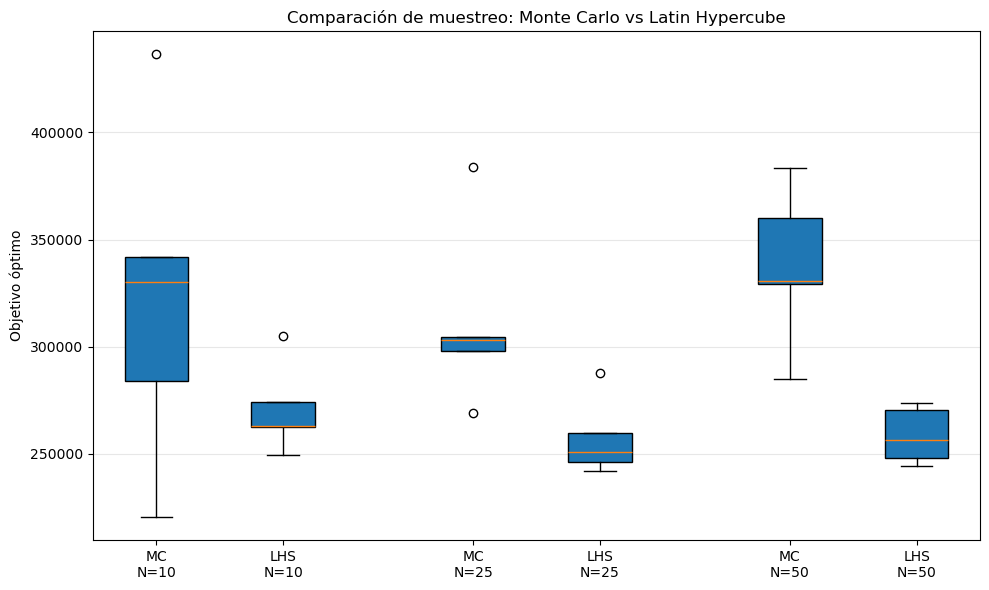

In [150]:
plt.figure(figsize=(10, 6))

positions = []
data = []
labels = []

pos = 1
for N in sorted(sampling_results["N"].unique()):
    for sampling in ["MC", "LHS"]:
        vals = sampling_results[
            (sampling_results["N"] == N) &
            (sampling_results["sampling"] == sampling)
        ]["objective"].values

        data.append(vals)
        positions.append(pos)
        labels.append(f"{sampling}\nN={N}")
        pos += 1

    pos += 0.5

plt.boxplot(data, positions=positions, patch_artist=True)

plt.xticks(positions, labels)
plt.ylabel("Objetivo óptimo")
plt.title("Comparación de muestreo: Monte Carlo vs Latin Hypercube")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

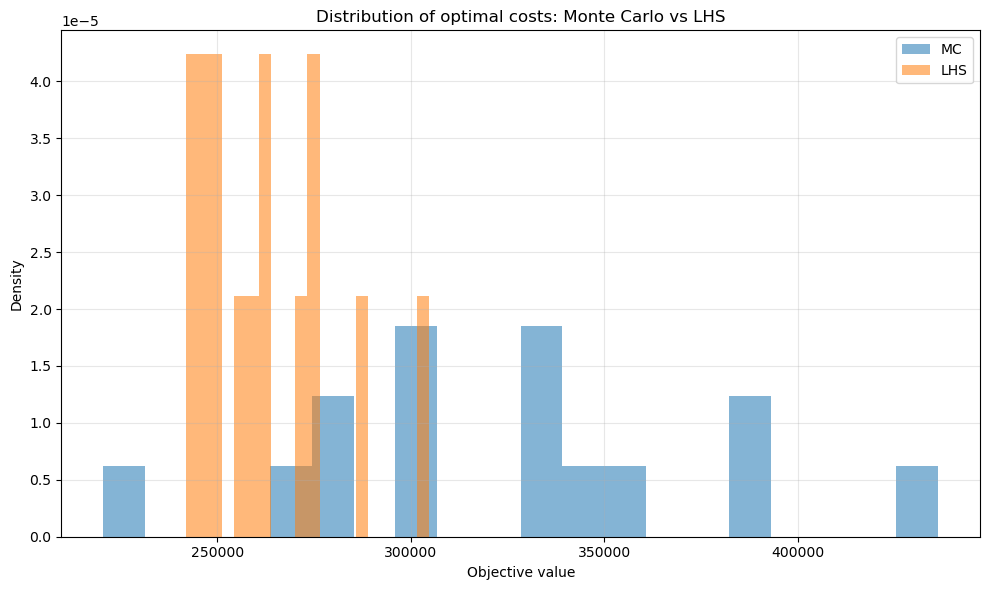

In [151]:
plt.figure(figsize=(10, 6))

for sampling in ["MC", "LHS"]:
    vals = sampling_results.loc[
        sampling_results["sampling"] == sampling,
        "objective"
    ].dropna().values

    plt.hist(
        vals,
        bins=20,
        alpha=0.55,
        density=True,
        label=sampling
    )

plt.xlabel("Objective value")
plt.ylabel("Density")
plt.title("Distribution of optimal costs: Monte Carlo vs LHS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

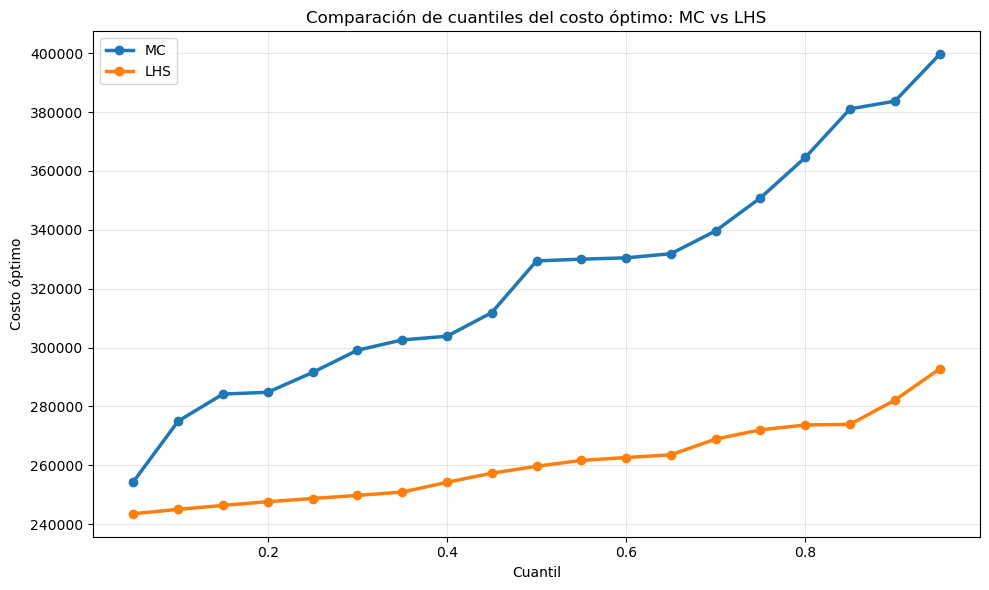

In [152]:
quantiles = np.linspace(0.05, 0.95, 19)

q_rows = []

for sampling in ["MC", "LHS"]:
    vals = sampling_results.loc[
        sampling_results["sampling"] == sampling,
        "objective"
    ].dropna().values

    qs = np.quantile(vals, quantiles)

    for q, val in zip(quantiles, qs):
        q_rows.append({
            "sampling": sampling,
            "quantile": q,
            "objective_quantile": val
        })

quantile_df = pd.DataFrame(q_rows)

plt.figure(figsize=(10, 6))

for sampling in ["MC", "LHS"]:
    df_s = quantile_df[quantile_df["sampling"] == sampling]

    plt.plot(
        df_s["quantile"],
        df_s["objective_quantile"],
        marker="o",
        linewidth=2.5,
        label=sampling
    )

plt.xlabel("Cuantil")
plt.ylabel("Costo óptimo")
plt.title("Comparación de cuantiles del costo óptimo: MC vs LHS")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

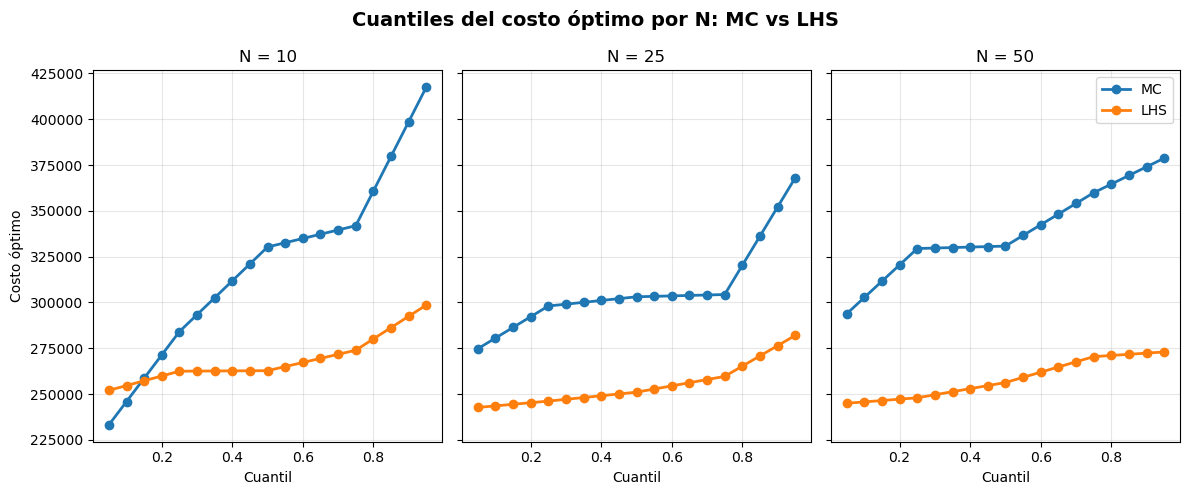

In [153]:
N_values = sorted(sampling_results["N"].unique())
quantiles = np.linspace(0.05, 0.95, 19)

fig, axes = plt.subplots(1, len(N_values), figsize=(4 * len(N_values), 5), sharey=True)

if len(N_values) == 1:
    axes = [axes]

for ax, N in zip(axes, N_values):

    for sampling in ["MC", "LHS"]:
        vals = sampling_results.loc[
            (sampling_results["N"] == N) &
            (sampling_results["sampling"] == sampling),
            "objective"
        ].dropna().values

        if len(vals) == 0:
            continue

        qs = np.quantile(vals, quantiles)

        ax.plot(
            quantiles,
            qs,
            marker="o",
            linewidth=2,
            label=sampling
        )

    ax.set_title(f"N = {N}")
    ax.set_xlabel("Cuantil")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Costo óptimo")
axes[-1].legend()

plt.suptitle("Cuantiles del costo óptimo por N: MC vs LHS", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Métricas de decisión: VSS, EVPI y CVaR

En esta sección se calculan métricas que permiten evaluar el valor de modelar explícitamente la incertidumbre.

- **RP:** costo óptimo del problema estocástico.
- **EEV:** costo esperado de usar la solución obtenida con parámetros promedio.
- **VSS:** valor de la solución estocástica.
- **WS:** solución Wait-and-See, donde se asume información perfecta.
- **EVPI:** valor esperado de la información perfecta.
- **CVaR:** medida de riesgo enfocada en los peores escenarios.

In [154]:
def generate_scenarios_with_regimes(
    nodes,
    edges,
    N=50,
    seed=123,
    min_mediocristan=5,
    min_extremistan=5,
    max_attempts=100,
    K=None,
    **scenario_kwargs
):
    """
    Genera escenarios hasta garantizar un número mínimo de escenarios
    Mediocristan (crisis=False) y Extremistan (crisis=True).

    Retorna:
    dfD, dfU, dfc, dfp, dfG
    """

    for attempt in range(max_attempts):

        current_seed = seed + attempt

        dfD, dfU, dfc, dfp, dfG = generate_scenarios_table(
            nodes=nodes,
            edges=edges,
            N=N,
            seed=current_seed,
            K=K,
            **scenario_kwargs
        )

        n_extreme = int(dfp["crisis"].sum())
        n_medio = int((dfp["crisis"] == False).sum())

        print(
            f"Attempt {attempt+1}: "
            f"Mediocristan={n_medio}, Extremistan={n_extreme}, seed={current_seed}"
        )

        if n_medio >= min_mediocristan and n_extreme >= min_extremistan:
            print("Escenarios válidos encontrados.")
            return dfD, dfU, dfc, dfp, dfG

    raise RuntimeError(
        f"No se lograron generar suficientes escenarios extremos después de {max_attempts} intentos. "
        f"Prueba aumentar N o aumentar p_crisis."
    )

In [155]:
dfD, dfU, dfc, dfp, dfG = generate_scenarios_with_regimes(
    nodes=nodes,
    edges=edges,
    N=100,
    seed=123,
    min_mediocristan=10,
    min_extremistan=10,
    p_crisis=0.15
)

omegas, p_omega, D, U_ew, c_ew, G_iw = build_scenario_data(
    dfD,
    dfU,
    dfc,
    dfG,
    dfp
)

base = build_base_data(
    nodes,
    edges,
    dfD=dfD,
    H_value=50.0,
    budget=BUDGET
)

Attempt 1: Mediocristan=85, Extremistan=15, seed=123
Escenarios válidos encontrados.


In [156]:
omegas_medio = dfp.loc[dfp["crisis"] == False, "omega"].tolist()

omegas_extremo = dfp.loc[dfp["crisis"] == True, "omega"].tolist()

print("Escenarios Mediocristan:", len(omegas_medio))
print("Escenarios Extremistan:", len(omegas_extremo))

Escenarios Mediocristan: 85
Escenarios Extremistan: 15


In [157]:
def filter_scenario_set(
    omegas_subset,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw
):

    # Re-normalizar probabilidades
    total_prob = sum(p_omega[w] for w in omegas_subset)

    p_new = {
        w: p_omega[w] / total_prob
        for w in omegas_subset
    }

    D_new = {
        (w, i): val
        for (w, i), val in D.items()
        if w in omegas_subset
    }

    U_new = {
        (w, e): val
        for (w, e), val in U_ew.items()
        if w in omegas_subset
    }

    c_new = {
        (w, e): val
        for (w, e), val in c_ew.items()
        if w in omegas_subset
    }

    G_new = {
        (w, i): val
        for (w, i), val in G_iw.items()
        if w in omegas_subset
    }

    return (
        omegas_subset,
        p_new,
        D_new,
        U_new,
        c_new,
        G_new
    )

### RP

In [158]:
RP = benders_results["objective"]

print("RP =", RP)

RP = 219398.2812130186


### EEV

In [159]:
def build_expected_parameters(base, omegas, p_omega, D, U_ew, c_ew, G_iw):
    """
    Construye parámetros promedio para el modelo Expected Value.
    """

    demand_nodes = base["demand_nodes"]
    gen_nodes = base["gen_nodes"]
    edges_list = base["edges_list"]

    D_bar = {
        i: sum(p_omega[w] * D[(w, i)] for w in omegas)
        for i in demand_nodes
    }

    U_bar = {
        e: sum(p_omega[w] * U_ew[(w, e)] for w in omegas)
        for e in edges_list
    }

    c_bar = {
        e: sum(p_omega[w] * c_ew[(w, e)] for w in omegas)
        for e in edges_list
    }

    G_bar = {
        i: sum(p_omega[w] * G_iw[(w, i)] for w in omegas)
        for i in gen_nodes
    }

    return D_bar, U_bar, c_bar, G_bar

In [160]:
def solve_expected_value_problem(
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    delta_u=DELTA_U,
    budget=BUDGET,
    pi=PI
):
    """
    Resuelve el problema usando parámetros esperados.
    """

    D_bar, U_bar, c_bar, G_bar = build_expected_parameters(
        base, omegas, p_omega, D, U_ew, c_ew, G_iw
    )

    m = gp.Model("Expected_Value")
    m.Params.OutputFlag = 0

    nodes_list = base["nodes_list"]
    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]
    gen_nodes = base["gen_nodes"]
    in_arcs = base["in_arcs"]
    out_arcs = base["out_arcs"]
    H_e = base["H_e"]

    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")
    f = m.addVars(edges_list, lb=0, name="f")
    delta = m.addVars(demand_nodes, lb=0, name="delta")
    g = m.addVars(gen_nodes, lb=0, name="g")

    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    for e in edges_list:
        m.addConstr(
            f[e] <= U_bar[e] * (1 + delta_u * h[e]),
            name=f"cap_{e}"
        )

    for i in gen_nodes:
        m.addConstr(g[i] <= G_bar[i], name=f"gen_{i}")

    for i in demand_nodes:
        m.addConstr(delta[i] <= D_bar[i], name=f"delta_{i}")

    for i in nodes_list:
        inflow = gp.quicksum(f[e] for e in in_arcs.get(i, []))
        outflow = gp.quicksum(f[e] for e in out_arcs.get(i, []))

        if i in demand_nodes:
            m.addConstr(inflow - outflow == D_bar[i] - delta[i])
        elif i in gen_nodes:
            m.addConstr(inflow - outflow == -g[i])
        else:
            m.addConstr(inflow - outflow == 0)

    invest = gp.quicksum(H_e[e] * h[e] for e in edges_list)
    op_cost = gp.quicksum(c_bar[e] * f[e] for e in edges_list)
    ens_cost = pi * gp.quicksum(delta[i] for i in demand_nodes)

    m.setObjective(invest + op_cost + ens_cost, GRB.MINIMIZE)
    m.optimize()

    h_sol = {e: round(h[e].X) for e in edges_list}
    selected_edges = [e for e in edges_list if h_sol[e] > 0.5]

    return {
        "objective": m.ObjVal,
        "h_sol": h_sol,
        "selected_edges": selected_edges,
        "num_selected_edges": len(selected_edges)
    }

### EVPI: ¿Cuánto pagaría por conocer el escenario futuro antes de decidir?

### WS

In [161]:
def solve_wait_and_see_single(
    base,
    w,
    D,
    U_ew,
    c_ew,
    G_iw,
    delta_u=DELTA_U,
    budget=BUDGET,
    pi=PI
):
    """
    Resuelve el problema con información perfecta para un escenario w.
    Es decir, h se decide sabiendo que ocurrirá ese escenario.
    """

    m = gp.Model(f"WS_{w}")
    m.Params.OutputFlag = 0

    nodes_list = base["nodes_list"]
    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]
    gen_nodes = base["gen_nodes"]
    in_arcs = base["in_arcs"]
    out_arcs = base["out_arcs"]
    H_e = base["H_e"]

    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")
    f = m.addVars(edges_list, lb=0, name="f")
    delta = m.addVars(demand_nodes, lb=0, name="delta")
    g = m.addVars(gen_nodes, lb=0, name="g")

    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    for e in edges_list:
        m.addConstr(
            f[e] <= U_ew[(w, e)] * (1 + delta_u * h[e])
        )

    for i in gen_nodes:
        m.addConstr(g[i] <= G_iw[(w, i)])

    for i in demand_nodes:
        m.addConstr(delta[i] <= D[(w, i)])

    for i in nodes_list:
        inflow = gp.quicksum(f[e] for e in in_arcs.get(i, []))
        outflow = gp.quicksum(f[e] for e in out_arcs.get(i, []))

        if i in demand_nodes:
            m.addConstr(inflow - outflow == D[(w, i)] - delta[i])
        elif i in gen_nodes:
            m.addConstr(inflow - outflow == -g[i])
        else:
            m.addConstr(inflow - outflow == 0)

    invest = gp.quicksum(H_e[e] * h[e] for e in edges_list)
    op_cost = gp.quicksum(c_ew[(w, e)] * f[e] for e in edges_list)
    ens_cost = pi * gp.quicksum(delta[i] for i in demand_nodes)

    m.setObjective(invest + op_cost + ens_cost, GRB.MINIMIZE)
    m.optimize()

    return m.ObjVal

In [162]:
def compute_WS(
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    delta_u=DELTA_U,
    budget=BUDGET,
    pi=PI
):
    """
    Calcula WS = suma_w p_w * z_w^WS.
    """

    rows = []
    WS = 0.0

    for w in omegas:
        ws_w = solve_wait_and_see_single(
            base=base,
            w=w,
            D=D,
            U_ew=U_ew,
            c_ew=c_ew,
            G_iw=G_iw,
            delta_u=delta_u,
            budget=budget,
            pi=pi
        )

        WS += p_omega[w] * ws_w

        rows.append({
            "omega": w,
            "p_omega": p_omega[w],
            "WS_w": ws_w
        })

    return WS, pd.DataFrame(rows)

### CVAR

In [163]:
def empirical_var_cvar(costs, probs, beta=0.90):
    """
    Calcula VaR_beta y CVaR_beta empíricos con probabilidades.
    beta = nivel de confianza. Ej: beta=0.90.
    """

    costs = np.asarray(costs, dtype=float)
    probs = np.asarray(probs, dtype=float)

    idx = np.argsort(costs)
    costs_sorted = costs[idx]
    probs_sorted = probs[idx]

    cum_probs = np.cumsum(probs_sorted)

    var_idx = np.searchsorted(cum_probs, beta)
    var_idx = min(var_idx, len(costs_sorted) - 1)

    VaR = costs_sorted[var_idx]

    tail_mask = costs_sorted >= VaR
    tail_prob = probs_sorted[tail_mask].sum()

    if tail_prob <= 0:
        CVaR = VaR
    else:
        CVaR = np.sum(costs_sorted[tail_mask] * probs_sorted[tail_mask]) / tail_prob

    return VaR, CVaR

In [164]:
def solve_cvar_model(
    base,
    omegas,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw,
    beta=0.90,
    delta_u=DELTA_U,
    budget=BUDGET,
    pi=PI
):
    """
    Modelo risk-averse que minimiza inversión + CVaR_beta del costo de segunda etapa.

    Si beta=0.90, se minimiza el promedio de la peor cola del 10%.
    """

    m = gp.Model(f"CVaR_{beta}")
    m.Params.OutputFlag = 0

    nodes_list = base["nodes_list"]
    edges_list = base["edges_list"]
    demand_nodes = base["demand_nodes"]
    gen_nodes = base["gen_nodes"]
    in_arcs = base["in_arcs"]
    out_arcs = base["out_arcs"]
    H_e = base["H_e"]

    h = m.addVars(edges_list, vtype=GRB.BINARY, name="h")
    f = m.addVars(edges_list, omegas, lb=0, name="f")
    delta = m.addVars(demand_nodes, omegas, lb=0, name="delta")
    g = m.addVars(gen_nodes, omegas, lb=0, name="g")

    eta = m.addVar(lb=-GRB.INFINITY, name="eta")
    u = m.addVars(omegas, lb=0, name="u")

    m.addConstr(
        gp.quicksum(H_e[e] * h[e] for e in edges_list) <= budget,
        name="budget"
    )

    Q = {}

    for w in omegas:

        for e in edges_list:
            m.addConstr(
                f[e, w] <= U_ew[(w, e)] * (1 + delta_u * h[e])
            )

        for i in gen_nodes:
            m.addConstr(g[i, w] <= G_iw[(w, i)])

        for i in demand_nodes:
            m.addConstr(delta[i, w] <= D[(w, i)])

        for i in nodes_list:
            inflow = gp.quicksum(f[e, w] for e in in_arcs.get(i, []))
            outflow = gp.quicksum(f[e, w] for e in out_arcs.get(i, []))

            if i in demand_nodes:
                m.addConstr(inflow - outflow == D[(w, i)] - delta[i, w])
            elif i in gen_nodes:
                m.addConstr(inflow - outflow == -g[i, w])
            else:
                m.addConstr(inflow - outflow == 0)

        Q[w] = (
            gp.quicksum(c_ew[(w, e)] * f[e, w] for e in edges_list)
            +
            pi * gp.quicksum(delta[i, w] for i in demand_nodes)
        )

        m.addConstr(u[w] >= Q[w] - eta)

    invest = gp.quicksum(H_e[e] * h[e] for e in edges_list)

    cvar_expr = eta + (1.0 / (1.0 - beta)) * gp.quicksum(
        p_omega[w] * u[w] for w in omegas
    )

    m.setObjective(invest + cvar_expr, GRB.MINIMIZE)
    m.optimize()

    h_sol = {e: round(h[e].X) for e in edges_list}
    selected_edges = [e for e in edges_list if h_sol[e] > 0.5]

    return {
        "objective": m.ObjVal,
        "h_sol": h_sol,
        "selected_edges": selected_edges,
        "num_selected_edges": len(selected_edges),
        "eta": eta.X,
        "cvar_term": cvar_expr.getValue(),
        "investment_cost": sum(H_e[e] * h_sol[e] for e in edges_list)
    }

## Métricas

In [165]:
def compute_decision_metrics_for_regime(
    regime_name,
    base,
    omegas_regime,
    p_regime,
    D_regime,
    U_regime,
    c_regime,
    G_regime,
    beta=0.90
):
    """
    Calcula RP, EEV, VSS, WS, EVPI, CVaR neutral y CVaR risk-averse
    para un conjunto de escenarios filtrado.
    """

    # RP: solución estocástica neutral al riesgo
    rp_res = solve_DE(
        base,
        omegas_regime,
        p_regime,
        D_regime,
        U_regime,
        c_regime,
        G_regime
    )

    RP = rp_res["objective"]

    # EV: solución basada en valores esperados
    ev_res = solve_expected_value_problem(
        base,
        omegas_regime,
        p_regime,
        D_regime,
        U_regime,
        c_regime,
        G_regime
    )

    ev_eval = evaluate_solution(
        h_hat=ev_res["h_sol"],
        base=base,
        omegas=omegas_regime,
        p_omega=p_regime,
        D=D_regime,
        U_ew=U_regime,
        c_ew=c_regime,
        G_iw=G_regime
    )

    EEV = ev_eval["total_expected_cost"]

    VSS = EEV - RP

    # WS
    WS, ws_table = compute_WS(
        base,
        omegas_regime,
        p_regime,
        D_regime,
        U_regime,
        c_regime,
        G_regime
    )

    EVPI = RP - WS

    # CVaR solución neutral
    rp_eval = evaluate_solution(
        h_hat=rp_res["h_sol"],
        base=base,
        omegas=omegas_regime,
        p_omega=p_regime,
        D=D_regime,
        U_ew=U_regime,
        c_ew=c_regime,
        G_iw=G_regime
    )

    VaR_neutral, CVaR_neutral = empirical_var_cvar(
        rp_eval["scenario_costs"]["total_cost_scenario"].values,
        rp_eval["scenario_costs"]["p_omega"].values,
        beta=beta
    )

    # CVaR risk-averse
    risk_res = solve_cvar_model(
        base,
        omegas_regime,
        p_regime,
        D_regime,
        U_regime,
        c_regime,
        G_regime,
        beta=beta
    )

    risk_eval = evaluate_solution(
        h_hat=risk_res["h_sol"],
        base=base,
        omegas=omegas_regime,
        p_omega=p_regime,
        D=D_regime,
        U_ew=U_regime,
        c_ew=c_regime,
        G_iw=G_regime
    )

    VaR_risk, CVaR_risk = empirical_var_cvar(
        risk_eval["scenario_costs"]["total_cost_scenario"].values,
        risk_eval["scenario_costs"]["p_omega"].values,
        beta=beta
    )

    return {
        "regime": regime_name,
        "RP": RP,
        "EEV": EEV,
        "VSS": VSS,
        "WS": WS,
        "EVPI": EVPI,
        "CVaR_neutral": CVaR_neutral,
        "CVaR_risk_averse": CVaR_risk,
        "rp_solution": rp_res,
        "ev_solution": ev_res,
        "risk_solution": risk_res,
        "rp_eval": rp_eval,
        "risk_eval": risk_eval,
        "ws_table": ws_table
    }

In [166]:
omegas_medio = dfp.loc[dfp["crisis"] == False, "omega"].tolist()
omegas_extremo = dfp.loc[dfp["crisis"] == True, "omega"].tolist()

print("Mediocristan:", len(omegas_medio))
print("Extremistan:", len(omegas_extremo))

(
    omegas_M, p_M, D_M, U_M, c_M, G_M
) = filter_scenario_set(
    omegas_medio,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw
)

(
    omegas_E, p_E, D_E, U_E, c_E, G_E
) = filter_scenario_set(
    omegas_extremo,
    p_omega,
    D,
    U_ew,
    c_ew,
    G_iw
)

Mediocristan: 85
Extremistan: 15


In [167]:
metrics_M = compute_decision_metrics_for_regime(
    regime_name="Mediocristan",
    base=base,
    omegas_regime=omegas_M,
    p_regime=p_M,
    D_regime=D_M,
    U_regime=U_M,
    c_regime=c_M,
    G_regime=G_M,
    beta=0.90
)

metrics_E = compute_decision_metrics_for_regime(
    regime_name="Extremistan",
    base=base,
    omegas_regime=omegas_E,
    p_regime=p_E,
    D_regime=D_E,
    U_regime=U_E,
    c_regime=c_E,
    G_regime=G_E,
    beta=0.90
)

In [168]:
metrics_table = pd.DataFrame([
    {
        "Métrica": "RP (objetivo estocástico)",
        "Mediocristan": metrics_M["RP"],
        "Extremistan": metrics_E["RP"]
    },
    {
        "Métrica": "EEV (costo de ignorar incertidumbre)",
        "Mediocristan": metrics_M["EEV"],
        "Extremistan": metrics_E["EEV"]
    },
    {
        "Métrica": "VSS",
        "Mediocristan": metrics_M["VSS"],
        "Extremistan": metrics_E["VSS"]
    },
    {
        "Métrica": "WS (wait-and-see)",
        "Mediocristan": metrics_M["WS"],
        "Extremistan": metrics_E["WS"]
    },
    {
        "Métrica": "EVPI",
        "Mediocristan": metrics_M["EVPI"],
        "Extremistan": metrics_E["EVPI"]
    },
    {
        "Métrica": "CVaR90 solución neutral",
        "Mediocristan": metrics_M["CVaR_neutral"],
        "Extremistan": metrics_E["CVaR_neutral"]
    },
    {
        "Métrica": "CVaR90 solución risk-averse",
        "Mediocristan": metrics_M["CVaR_risk_averse"],
        "Extremistan": metrics_E["CVaR_risk_averse"]
    }
])

metrics_table_formatted = metrics_table.copy()

for col in ["Mediocristan", "Extremistan"]:
    metrics_table_formatted[col] = metrics_table_formatted[col].map(lambda x: f"{x:,.2f}")

metrics_table_formatted

,Métrica,Mediocristan,Extremistan
0,RP (objetivo estocástico),"221,408.55","884,733.01"
1,EEV (costo de ignorar incertidumbre),"223,377.30","886,219.82"
2,VSS,"1,968.75","1,486.81"
3,WS (wait-and-see),"221,090.63","884,394.63"
4,EVPI,317.92,338.38
5,CVaR90 solución neutral,"230,398.53","1,125,840.54"
6,CVaR90 solución risk-averse,"230,263.96","1,125,540.54"


Los resultados muestran diferencias claras entre los regímenes de incertidumbre tipo Mediocristan y Extremistan.

En el caso de Mediocristan, los costos esperados son relativamente moderados y las pérdidas extremas permanecen controladas. El valor del programa estocástico (RP) es menor que el EEV, generando un VSS positivo de aproximadamente 1,969. Esto indica que modelar explícitamente la incertidumbre sí produce decisiones mejores que usar únicamente valores promedio. Además, el EVPI es relativamente bajo (317.92), lo cual sugiere que conocer perfectamente el futuro no tendría un beneficio económico extremadamente alto bajo escenarios moderados.

Por otro lado, en Extremistan los costos crecen drásticamente debido a escenarios severos de crisis, fallas de capacidad y alta demanda. El RP supera los 884 mil y el CVaR90 aumenta hasta valores cercanos a 1.13 millones, evidenciando colas pesadas y pérdidas extremas significativas. Aunque el VSS sigue siendo positivo, su magnitud relativa es menor respecto al tamaño total del problema, indicando que incluso optimizando estocásticamente, los eventos extremos siguen dominando el comportamiento del sistema.

El EVPI en Extremistan también aumenta ligeramente, mostrando que la información perfecta adquiere mayor valor económico cuando predominan eventos extremos. Finalmente, la solución aversa al riesgo logra reducir el CVaR90 tanto en Mediocristan como en Extremistan, aunque el efecto es mucho más relevante bajo colas extremas, donde la reducción de pérdidas severas es precisamente el objetivo principal de la optimización CVaR.

## 5. Backtesting extendido

En esta sección se evalúan las soluciones obtenidas en un conjunto nuevo de escenarios fuera de muestra.

El objetivo es analizar qué tan robustas son las decisiones cuando se enfrentan a realizaciones nuevas del mundo W.

Se comparan:

- solución estocástica neutral al riesgo,
- solución de valor esperado,
- solución aversa al riesgo CVaR.

Para cada solución se calcula:

- costo promedio fuera de muestra,
- VaR95,
- CVaR95,
- déficit promedio,
- proporción de escenarios con déficit.

In [169]:
def run_extended_backtesting(
    solutions_dict,
    nodes,
    edges,
    base,
    N_out=250,
    seed=2026,
    min_mediocristan=20,
    min_extremistan=20,
    p_crisis=0.15,
    beta=0.95
):
    """
    Evalúa soluciones fuera de muestra usando un nuevo conjunto de escenarios W.
    """

    dfD_out, dfU_out, dfc_out, dfp_out, dfG_out = generate_scenarios_with_regimes(
        nodes=nodes,
        edges=edges,
        N=N_out,
        seed=seed,
        min_mediocristan=min_mediocristan,
        min_extremistan=min_extremistan,
        p_crisis=p_crisis
    )

    omegas_out, p_out, D_out, U_out, c_out, G_out = build_scenario_data(
        dfD_out,
        dfU_out,
        dfc_out,
        dfG_out,
        dfp_out
    )

    rows = []
    scenario_rows = []

    for sol_name, h_sol in solutions_dict.items():

        print(f"Evaluando solución fuera de muestra: {sol_name}")

        eval_sol = evaluate_solution(
            h_hat=h_sol,
            base=base,
            omegas=omegas_out,
            p_omega=p_out,
            D=D_out,
            U_ew=U_out,
            c_ew=c_out,
            G_iw=G_out
        )

        df_costs = eval_sol["scenario_costs"].copy()
        df_costs["solution"] = sol_name

        df_costs = df_costs.merge(
            dfp_out[["omega", "crisis"]],
            on="omega",
            how="left"
        )

        VaR95, CVaR95 = empirical_var_cvar(
            costs=df_costs["total_cost_scenario"].values,
            probs=df_costs["p_omega"].values,
            beta=beta
        )

        avg_deficit = df_costs["total_deficit"].mean()
        violation_rate = (df_costs["total_deficit"] > 1e-6).mean()

        rows.append({
            "Solución": sol_name,
            "Costo promedio out-of-sample": eval_sol["total_expected_cost"],
            "VaR95": VaR95,
            "CVaR95": CVaR95,
            "Déficit promedio": avg_deficit,
            "Tasa de escenarios con déficit": violation_rate,
            "Inversión": eval_sol["investment_cost"]
        })

        scenario_rows.append(df_costs)

    summary = pd.DataFrame(rows)
    scenario_detail = pd.concat(scenario_rows, ignore_index=True)

    return summary, scenario_detail, (dfD_out, dfU_out, dfc_out, dfp_out, dfG_out)

In [170]:
def extended_backtesting_metrics(
    backtest_detail,
    beta=0.95
):
    """
    Calcula métricas completas de backtesting
    separadas por solución y régimen.
    """

    rows = []

    for sol in backtest_detail["solution"].unique():

        for crisis_flag, regime_name in [
            (False, "Mediocristan"),
            (True, "Extremistan")
        ]:

            df_sub = backtest_detail[
                (backtest_detail["solution"] == sol)
                &
                (backtest_detail["crisis"] == crisis_flag)
            ].copy()

            costs = df_sub["total_cost_scenario"].values
            probs = df_sub["p_omega"].values

            VaR95, CVaR95 = empirical_var_cvar(
                costs,
                probs,
                beta=beta
            )

            # ====================================================
            # Restricciones
            # ====================================================

            deficit_violation = (
                df_sub["total_deficit"] > 1e-6
            ).mean()

            # proxy de servicio:
            # servicio fallido si déficit > 5% demanda promedio

            service_violation = (
                df_sub["total_deficit"]
                >
                0.05 * df_sub["total_deficit"].mean()
            ).mean()

            rows.append({

                "Solución": sol,

                "Régimen": regime_name,

                "Costo promedio (OoS)":
                    df_sub["total_cost_scenario"].mean(),

                "VaR95":
                    VaR95,

                "CVaR95":
                    CVaR95,

                "Déficit promedio":
                    df_sub["total_deficit"].mean(),

                "Tasa violación déficit":
                    deficit_violation,

                "Tasa violación servicio":
                    service_violation,

                "Costo máximo":
                    df_sub["total_cost_scenario"].max()
            })

    return pd.DataFrame(rows)

In [171]:
det_results = solve_expected_value_problem(
    base=base,
    omegas=omegas,
    p_omega=p_omega,
    D=D,
    U_ew=U_ew,
    c_ew=c_ew,
    G_iw=G_iw
)

In [172]:
solutions_dict = {
    "x_det": det_results["h_sol"],
    "x_sto": de_results["h_sol"],
    "x_risk": metrics_E["risk_solution"]["h_sol"],
    "x_EV": metrics_E["ev_solution"]["h_sol"]
}

In [173]:
backtest_summary, backtest_detail, backtest_scenarios = run_extended_backtesting(
    solutions_dict=solutions_dict,
    nodes=nodes,
    edges=edges,
    base=base,
    N_out=300,
    seed=2026,
    min_mediocristan=30,
    min_extremistan=30,
    p_crisis=0.15,
    beta=0.95
)
backtesting_metrics = extended_backtesting_metrics(
    backtest_detail,
    beta=0.95
)

backtesting_metrics

Attempt 1: Mediocristan=258, Extremistan=42, seed=2026
Escenarios válidos encontrados.
Evaluando solución fuera de muestra: x_det
Evaluando solución fuera de muestra: x_sto
Evaluando solución fuera de muestra: x_risk
Evaluando solución fuera de muestra: x_EV


,Solución,Régimen,Costo promedio (OoS),VaR95,CVaR95,Déficit promedio,Tasa violación déficit,Tasa violación servicio,Costo máximo
0,x_det,Mediocristan,221255.397395,2.382436e+05,2.382436e+05,618.170010,1.0,1.0,2.382436e+05
1,x_det,Extremistan,890747.289044,1.230325e+06,1.230325e+06,4530.025658,1.0,1.0,1.230325e+06
2,x_sto,Mediocristan,221255.397395,2.382436e+05,2.382436e+05,618.170010,1.0,1.0,2.382436e+05
3,x_sto,Extremistan,890747.289044,1.230325e+06,1.230325e+06,4530.025658,1.0,1.0,1.230325e+06
4,x_risk,Mediocristan,241079.154723,2.629904e+05,2.629904e+05,804.306505,1.0,1.0,2.629904e+05
5,x_risk,Extremistan,895364.461373,1.229825e+06,1.229825e+06,4573.990733,1.0,1.0,1.229825e+06
6,x_EV,Mediocristan,229346.180765,2.495395e+05,2.495395e+05,691.674328,1.0,1.0,2.495395e+05
7,x_EV,Extremistan,889570.660167,1.230475e+06,1.230475e+06,4521.838257,1.0,1.0,1.230475e+06


In [174]:
backtesting_metrics_fmt = backtesting_metrics.copy()

num_cols = [
    "Costo promedio (OoS)",
    "VaR95",
    "CVaR95",
    "Déficit promedio",
    "Costo máximo"
]

for c in num_cols:
    backtesting_metrics_fmt[c] = (
        backtesting_metrics_fmt[c]
        .map(lambda x: f"{x:,.2f}")
    )

backtesting_metrics_fmt

,Solución,Régimen,Costo promedio (OoS),VaR95,CVaR95,Déficit promedio,Tasa violación déficit,Tasa violación servicio,Costo máximo
0,x_det,Mediocristan,"221,255.40","238,243.60","238,243.60",618.17,1.0,1.0,"238,243.60"
1,x_det,Extremistan,"890,747.29","1,230,325.01","1,230,325.01","4,530.03",1.0,1.0,"1,230,325.01"
2,x_sto,Mediocristan,"221,255.40","238,243.60","238,243.60",618.17,1.0,1.0,"238,243.60"
3,x_sto,Extremistan,"890,747.29","1,230,325.01","1,230,325.01","4,530.03",1.0,1.0,"1,230,325.01"
4,x_risk,Mediocristan,"241,079.15","262,990.39","262,990.39",804.31,1.0,1.0,"262,990.39"
5,x_risk,Extremistan,"895,364.46","1,229,825.01","1,229,825.01","4,573.99",1.0,1.0,"1,229,825.01"
6,x_EV,Mediocristan,"229,346.18","249,539.51","249,539.51",691.67,1.0,1.0,"249,539.51"
7,x_EV,Extremistan,"889,570.66","1,230,475.01","1,230,475.01","4,521.84",1.0,1.0,"1,230,475.01"


La tabla de métricas evidencia diferencias importantes entre las soluciones evaluadas bajo escenarios fuera de muestra. En primer lugar, la solución estocástica neutral al riesgo ($x_{sto}$) y la solución determinística ($x_{det}$) presentan prácticamente el mismo desempeño, lo que sugiere que, para esta red y nivel de presupuesto, ambas metodologías terminan seleccionando decisiones de inversión muy similares. Estas soluciones logran los menores costos promedio y los menores niveles de déficit bajo escenarios Mediocristan, indicando un buen desempeño bajo condiciones relativamente normales.

Por otro lado, la solución aversa al riesgo ($x_{risk}$) presenta costos promedio y déficits más altos, especialmente en escenarios Mediocristan. Esto refleja el costo asociado a incorporar robustez frente a eventos extremos. Sin embargo, bajo escenarios Extremistan, la diferencia entre soluciones se reduce considerablemente, ya que todas experimentan incrementos severos en costos, VaR95 y CVaR95 debido al impacto dominante de eventos extremos y fallas sistémicas en la red.

Adicionalmente, el hecho de que todas las soluciones presenten tasas de violación de déficit y servicio iguales a 1.0 indica que, en todos los escenarios, existe algún nivel de demanda no satisfecha. Esto sugiere que la red opera permanentemente bajo estrés y que el presupuesto disponible no es suficiente para eliminar completamente las pérdidas bajo condiciones adversas.

## Gráficas

C:\Users\Usuario\AppData\Local\Temp\ipykernel_12968\3203269229.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, patch_artist=True, showmeans=True)


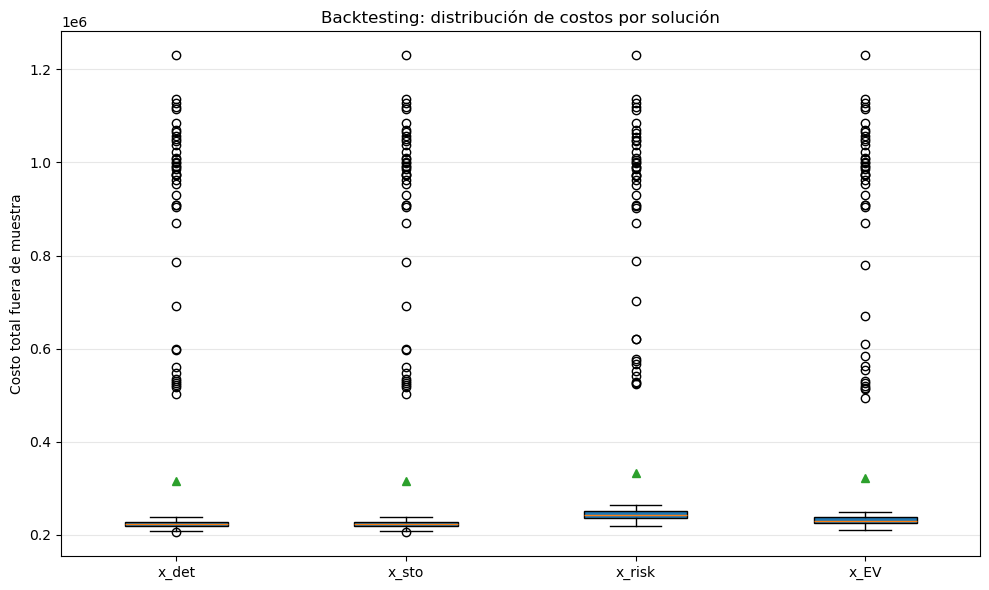

In [175]:
plt.figure(figsize=(10, 6))

data = [
    backtest_detail.loc[backtest_detail["solution"] == s, "total_cost_scenario"].values
    for s in backtest_detail["solution"].unique()
]

labels = backtest_detail["solution"].unique()

plt.boxplot(data, labels=labels, patch_artist=True, showmeans=True)

plt.ylabel("Costo total fuera de muestra")
plt.title("Backtesting: distribución de costos por solución")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

La solución aversa al riesgo ($x_{risk}$) desplaza toda la distribución hacia costos más altos, lo cual evidencia que protegerse frente a eventos extremos implica sacrificar desempeño promedio.

Sin embargo, incluso la política risk-averse continúa presentando outliers extremos de gran magnitud. Esto indica que la aversión al riesgo no logra eliminar completamente las pérdidas severas, sino únicamente amortiguarlas marginalmente. En consecuencia, el sistema continúa siendo altamente vulnerable frente a escenarios extremos de gran impacto.

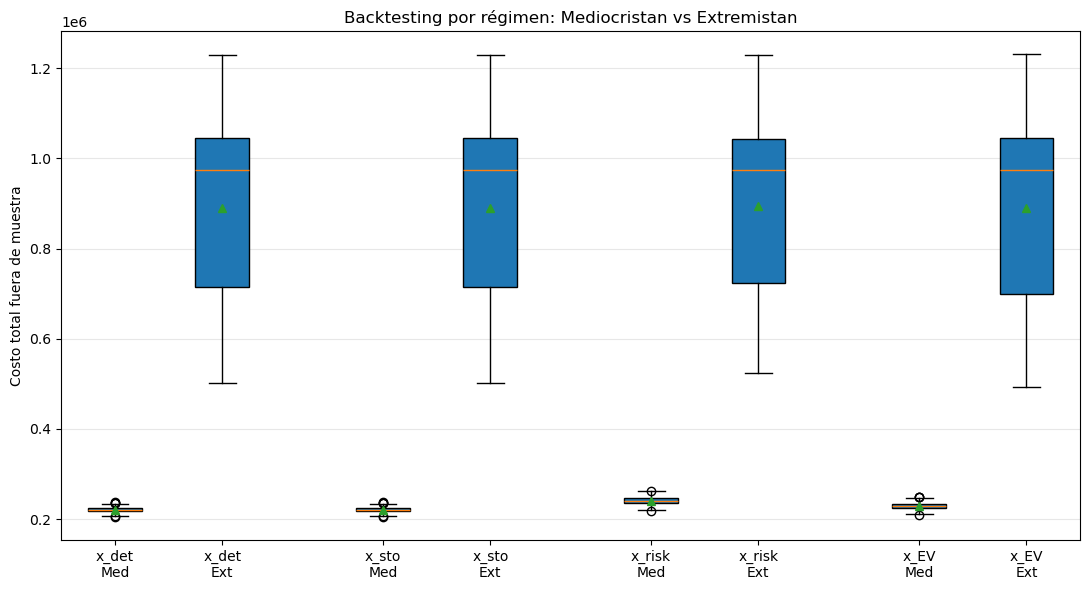

In [176]:
plt.figure(figsize=(11, 6))

solutions = backtest_detail["solution"].unique()
positions = []
data = []
labels = []

pos = 1

for sol in solutions:
    for crisis_flag, regime in [(False, "Med"), (True, "Ext")]:
        vals = backtest_detail.loc[
            (backtest_detail["solution"] == sol) &
            (backtest_detail["crisis"] == crisis_flag),
            "total_cost_scenario"
        ].values

        data.append(vals)
        positions.append(pos)
        labels.append(f"{sol}\n{regime}")
        pos += 1

    pos += 0.5

plt.boxplot(data, positions=positions, patch_artist=True, showmeans=True)

plt.xticks(positions, labels)
plt.ylabel("Costo total fuera de muestra")
plt.title("Backtesting por régimen: Mediocristan vs Extremistan")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Bajo escenarios Mediocristan, todas las políticas presentan cajas compactas y baja dispersión, reflejando un comportamiento relativamente estable y predecible. Por otro lado, los eventos extremos dominan completamente la variabilidad del sistema y generan costos mucho mayores que los observados en escenarios normales. También puede observarse que las diferencias entre soluciones se vuelven mucho menos significativas en Extremistan.



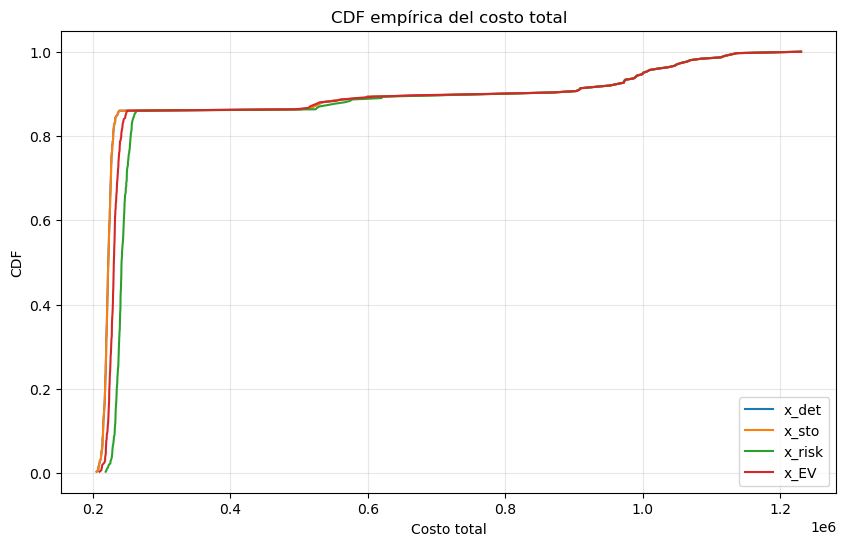

In [177]:
plt.figure(figsize=(10,6))

for sol in backtest_detail["solution"].unique():

    vals = np.sort(
        backtest_detail.loc[
            backtest_detail["solution"] == sol,
            "total_cost_scenario"
        ].values
    )

    cdf = np.arange(1, len(vals)+1) / len(vals)

    plt.plot(vals, cdf, label=sol)

plt.xlabel("Costo total")
plt.ylabel("CDF")
plt.title("CDF empírica del costo total")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Las curvas muestran inicialmente un crecimiento muy rápido alrededor de los costos bajos, lo que indica que una gran proporción de escenarios corresponde a realizaciones relativamente moderadas asociadas a Mediocristan.

Posteriormente, las curvas presentan una cola larga que se extiende hasta valores superiores a 1.2 millones, reflejando nuevamente la presencia de eventos extremos de gran severidad. Este comportamiento confirma que la distribución de costos posee colas pesadas y que los escenarios Extremistan tienen una influencia significativa sobre las métricas de riesgo.

Es importante resaltar que muchos de los resultados observados están fuertemente influenciados por la instancia específica utilizada en este estudio. La red seleccionada presenta una combinación particular de tamaño, distribución de generación, capacidad de transmisión y presupuesto de inversión, lo cual condiciona directamente el comportamiento de las soluciones. En particular, la alta frecuencia de déficit y la similitud entre algunas políticas de inversión sugieren que esta instancia posee limitaciones estructurales importantes y una vulnerabilidad significativa frente a escenarios extremos. 